# Stage 1: Dataset Exploration and Preprocessing

This notebook covers the initial stage of the machine learning pipeline, including dataset loading, exploration, visualization, and preprocessing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load and Explore the Dataset

In [2]:
# Define dataset path
dataset_path = Path('food_subset2')

# Get all class directories
classes = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

print("Number of classes:", len(classes))
print("Classes:", classes)

# Load dataset information
data_info = {}
for class_name in classes:
    class_path = dataset_path / class_name
    images = sorted(list(class_path.glob('*.jpg')))
    data_info[class_name] = len(images)

print("Dataset Overview")
print("Number of images per class:")
for class_name, count in data_info.items():
    print(class_name + ":", count)

total_images = sum(data_info.values())
print()
print("Total number of images:", total_images)
print("Average images per class:", round(total_images / len(classes), 2))

Number of classes: 5
Classes: ['donuts', 'falafel', 'ice_cream', 'pizza', 'spaghetti_bolognese']
Dataset Overview
Number of images per class:
donuts: 1000
falafel: 1000
ice_cream: 1000
pizza: 1000
spaghetti_bolognese: 1000

Total number of images: 5000
Average images per class: 1000.0


## 2. Display Sample Images

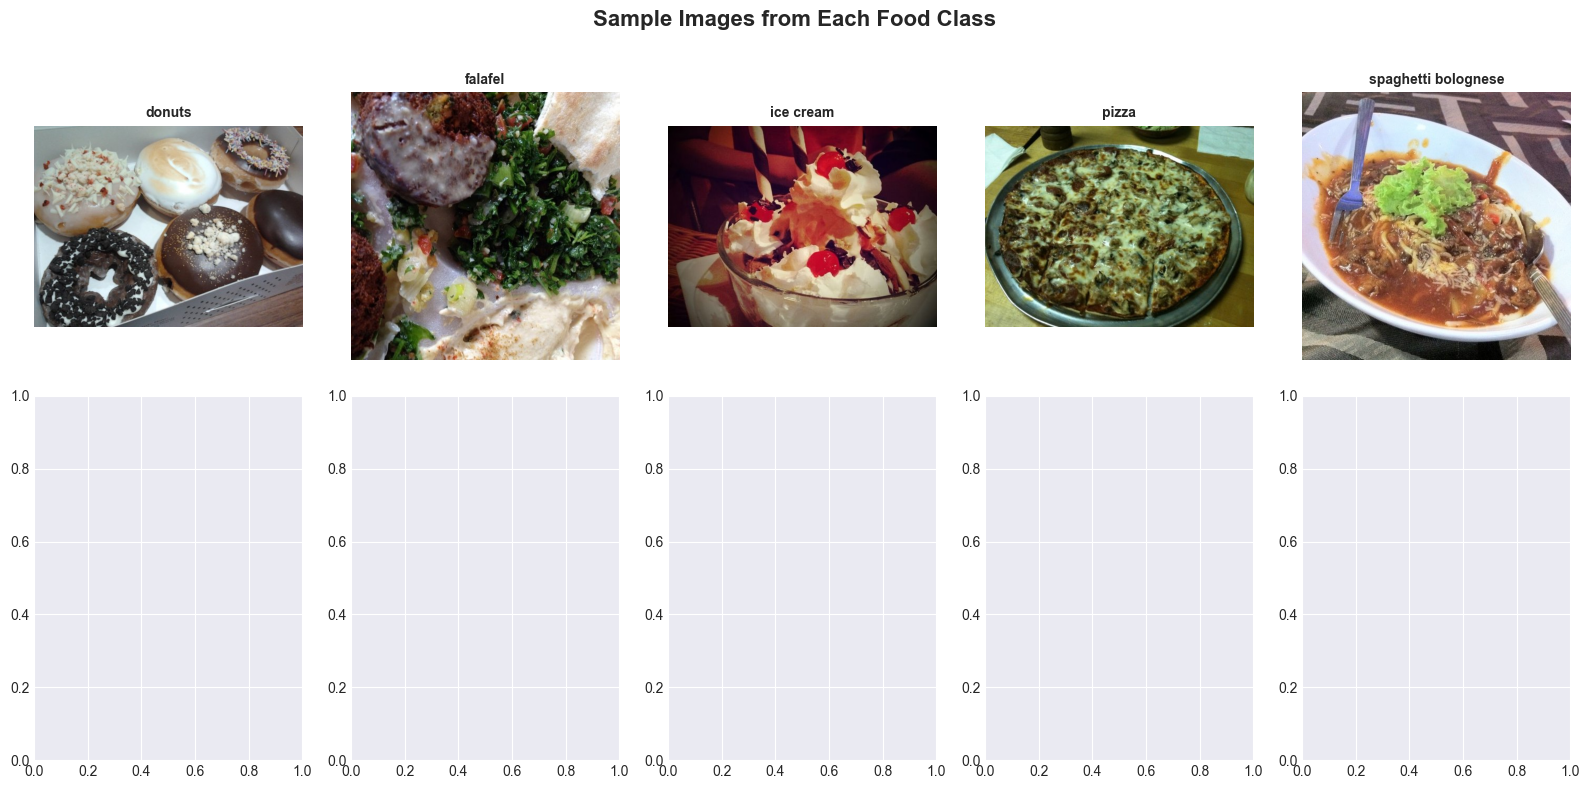

In [3]:
# Display sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle('Sample Images from Each Food Class', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, class_name in enumerate(classes):
    class_path = dataset_path / class_name
    images = sorted(list(class_path.glob('*.jpg')))
    if images:
        # Load first image from the class
        img = Image.open(images[107])
        axes[idx].imshow(img)
        axes[idx].set_title(class_name.replace('_', ' '), fontsize=10, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3. Analyze Class Distribution

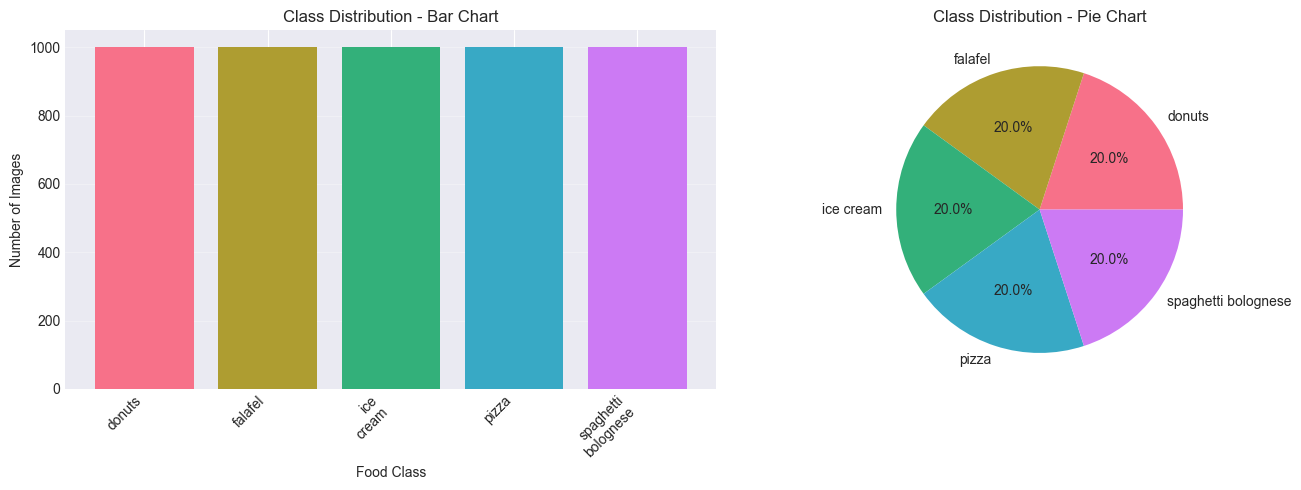

Class distribution stats
min: 1000
max: 1000
mean: 1000.0
std: 0.0
max/min ratio: 1.0


In [4]:
# Create visualizations for class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_names = list(data_info.keys())
class_counts = list(data_info.values())

axes[0].bar(range(len(class_names)), class_counts, color=sns.color_palette("husl", len(class_names)))
axes[0].set_xlabel('Food Class')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Class Distribution - Bar Chart')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_xticklabels([name.replace('_', '\n') for name in class_names], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_counts, labels=[name.replace('_', ' ') for name in class_names], autopct='%1.1f%%',
            colors=sns.color_palette("husl", len(class_names)))
axes[1].set_title('Class Distribution - Pie Chart')

plt.tight_layout()
plt.show()

# Simple class balance stats
counts = np.array(class_counts)
print('Class distribution stats')
print('min:', counts.min())
print('max:', counts.max())
print('mean:', round(counts.mean(), 2))
print('std:', round(counts.std(), 2))
print('max/min ratio:', round(counts.max() / counts.min(), 2))

## 4. Load and Resize Images

In [5]:
# Define target image size for resizing
TARGET_SIZE = 128  # Smaller size for faster and more stable training

# Function to load and resize images
def load_and_resize_images(dataset_path, classes, target_size=224):
    # Load all images from the dataset and resize them to target size.
    # Returns: images (array), labels (array), class_names (list)
    images = []
    labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_path = dataset_path / class_name
        image_files = sorted(list(class_path.glob('*.jpg')))
        
        for img_path in image_files:
            try:
                # Load image
                img = Image.open(img_path).convert('RGB')
                # Resize image
                img_resized = img.resize((target_size, target_size), Image.LANCZOS)
                # Convert to numpy array
                img_array = np.array(img_resized)
                
                images.append(img_array)
                labels.append(class_idx)
            except Exception as e:
                print('Error processing', img_path, ':', e)
                continue
        
        class_loaded_count = np.sum(np.array(labels) == class_idx)
        print('Loaded', class_loaded_count, 'images for class', class_name)
    
    return np.array(images), np.array(labels), classes

# Load and resize images
X, y, class_names = load_and_resize_images(dataset_path, classes, TARGET_SIZE)


print("\nDataset Loaded and Resized")

print('Dataset shape:', X.shape)
print('Labels shape:', y.shape)
print('Image dimensions:', str(TARGET_SIZE) + 'x' + str(TARGET_SIZE) + 'x3 (RGB)')
print('Unique classes:', np.unique(y))

Loaded 1000 images for class donuts
Loaded 1000 images for class falafel
Loaded 1000 images for class ice_cream
Loaded 1000 images for class pizza
Loaded 1000 images for class spaghetti_bolognese

Dataset Loaded and Resized
Dataset shape: (5000, 128, 128, 3)
Labels shape: (5000,)
Image dimensions: 128x128x3 (RGB)
Unique classes: [0 1 2 3 4]


## 5. Normalize Pixel Values

Original pixel value statistics:
  Min value: 0
  Max value: 255
  Mean value: 114.14
  Std deviation: 72.1

Normalized pixel value statistics (0-1 range):
  Min value: 0.0
  Max value: 1.0
  Mean value: 0.4476
  Std deviation: 0.2827


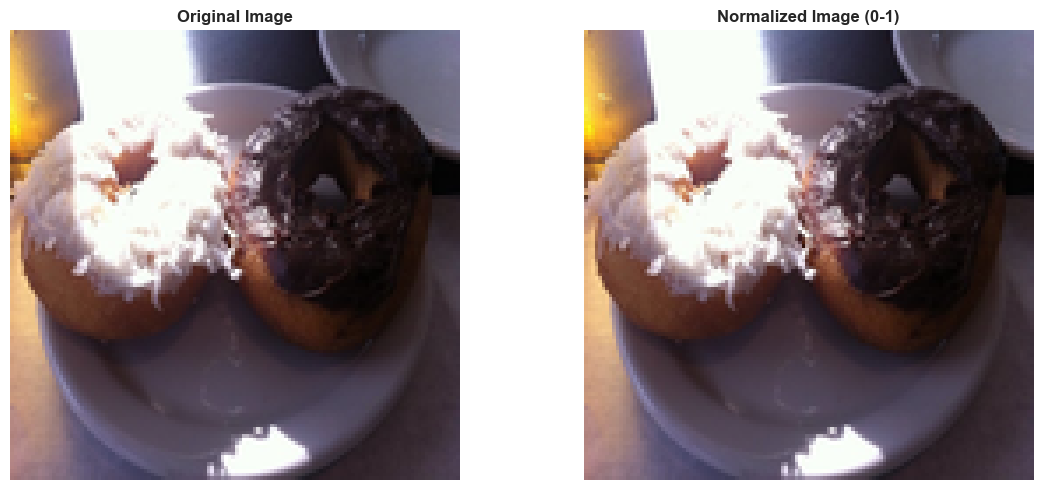

In [6]:
# Display original pixel value statistics
print("Original pixel value statistics:")
print('  Min value:', X.min())
print('  Max value:', X.max())
print('  Mean value:', round(X.mean(), 2))
print('  Std deviation:', round(X.std(), 2))

# Normalize pixel values to 0-1 range
X_normalized = X.astype('float32') / 255.0

# Display normalized pixel value statistics
print("\nNormalized pixel value statistics (0-1 range):")
print('  Min value:', round(X_normalized.min(), 4))
print('  Max value:', round(X_normalized.max(), 4))
print('  Mean value:', round(X_normalized.mean(), 4))
print('  Std deviation:', round(X_normalized.std(), 4))

# Visualize effect of normalization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original image
sample_idx = 850
axes[0].imshow(X[sample_idx].astype('uint8'))
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Normalized image
axes[1].imshow(X_normalized[sample_idx])
axes[1].set_title('Normalized Image (0-1)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Split Data into Training, Validation, and Testing Sets

In [7]:
# Define split ratios
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X_normalized, y, test_size=TEST_SIZE, random_state=42, stratify=y)

# Second split: separate train and validation from remaining data (70% train, 15% val)
val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size_adjusted, random_state=42, stratify=y_temp)

print("Data Split Summary:\n")
print('\nTotal dataset size:', format(len(X_normalized), ','), 'images')
print('\nTraining set size:', format(len(X_train), ','), 'images', '(' + str(round(len(X_train)/len(X_normalized)*100, 1)) + '%)')
print('Validation set size:', format(len(X_val), ','), 'images', '(' + str(round(len(X_val)/len(X_normalized)*100, 1)) + '%)')
print('Testing set size:', format(len(X_test), ','), 'images', '(' + str(round(len(X_test)/len(X_normalized)*100, 1)) + '%)')


Data Split Summary:


Total dataset size: 5,000 images

Training set size: 3,500 images (70.0%)
Validation set size: 750 images (15.0%)
Testing set size: 750 images (15.0%)


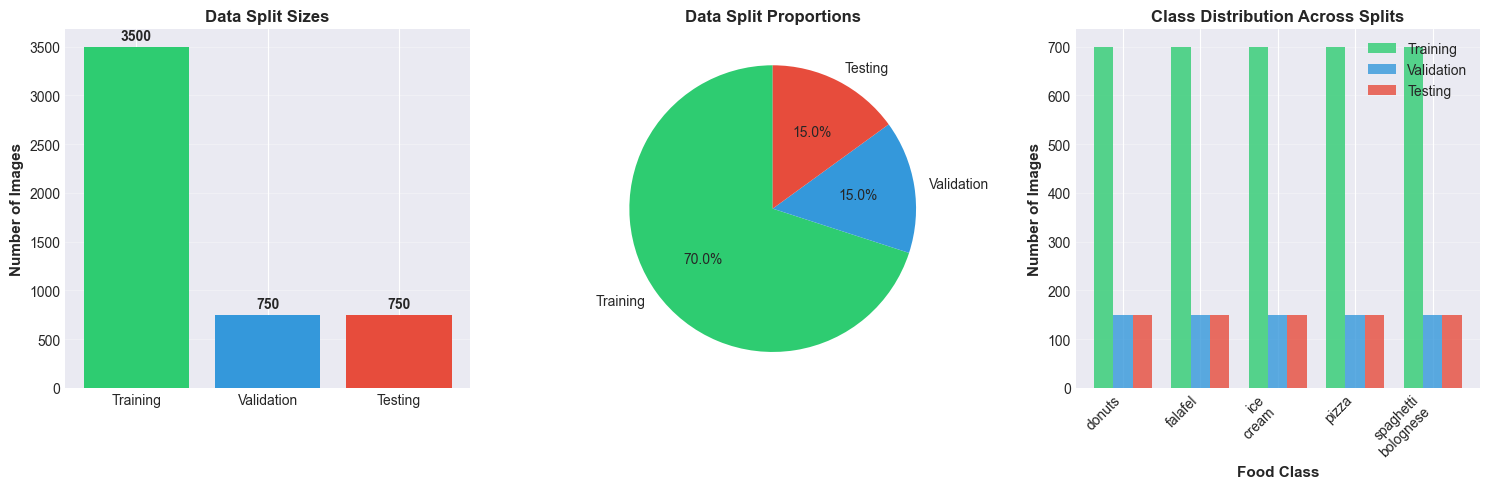

In [8]:
# Visualize the data split
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
split_names = ['Training', 'Validation', 'Testing']
split_sizes = [len(X_train), len(X_val), len(X_test)]
colors = ['#2ecc71', '#3498db', '#e74c3c']

# Bar chart of split sizes
axes[0].bar(split_names, split_sizes, color=colors)
axes[0].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[0].set_title('Data Split Sizes', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(split_sizes):
    axes[0].text(i, v + max(split_sizes)*0.02, str(v), ha='center', fontweight='bold')

# Pie chart of split proportions
axes[1].pie(split_sizes, labels=split_names, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Data Split Proportions', fontsize=12, fontweight='bold')

# Class distribution in train/val/test
y_sets = [y_train, y_val, y_test]
x_pos = np.arange(len(class_names))
width = 0.25

for i, (y_set, set_name, color) in enumerate(zip(y_sets, split_names, colors)):
    _, counts = np.unique(y_set, return_counts=True)
    axes[2].bar(x_pos + i*width, counts, width, label=set_name, color=color, alpha=0.8)

axes[2].set_xlabel('Food Class', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[2].set_title('Class Distribution Across Splits', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_pos + width)
axes[2].set_xticklabels([name.replace('_', '\n') for name in class_names], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Stage 2: Build a Custom CNN from Scratch

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,325 (16.36 MB)

 Trainable params: 4,288,325 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Total trainable parameters: 4,288,325
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.3354 - loss: 1.5197 - val_accuracy: 0.4320 - val_loss: 1.3606
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.4763 - loss: 1.2769 - val_accuracy: 0.4987 - val_loss: 1.2930
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.5531 - loss: 1.1233 - val_accuracy: 0.4893 - val_loss: 1.4171
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.6303 - loss: 0.9820 - val_accuracy: 0.5093 - val_loss: 1.4132
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.6886 - loss: 0.8404 - val_accuracy: 0.4667 - val_loss: 1.6970
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.7317 - loss: 0.7160 - val_accuracy: 0.5000 - val_loss: 1.6413
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.7723 - loss: 0.5918 - val_accuracy: 0.4920 - val_loss: 1.6976
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accu

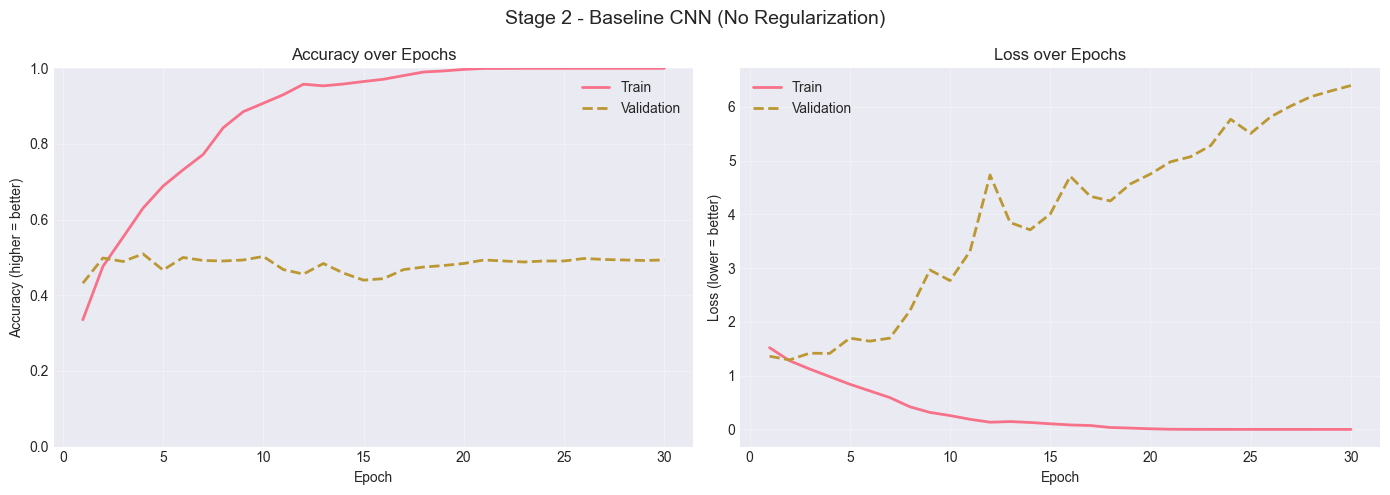

Stage 2 baseline results
train accuracy: 100.0 %
validation accuracy: 49.3 %
best validation accuracy: 50.9 %
test accuracy: 51.6 %
overfitting gap (train - val): 50.7 %


In [9]:
# Stage 2: Custom CNN from scratch — baseline (no regularization)
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

# Build the CNN manually
custom_cnn = models.Sequential([
    layers.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3)),

    # Block 1 — low-level features (edges, textures)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — mid-level features
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — high-level food-specific features
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to a vector
    layers.Flatten(),

    # Classifier head
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

custom_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary and trainable parameters
custom_cnn.summary()
print('Total trainable parameters:', format(custom_cnn.count_params(), ','))

# Train
history = custom_cnn.fit( X_train, y_train,validation_data=(X_val, y_val),epochs=30,batch_size=32,verbose=1)

#Accuracy and loss curves
history_dict = history.history
epochs_range = range(1, len(history_dict['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 2 - Baseline CNN (No Regularization)', fontsize=14)

axes[0].plot(epochs_range, history_dict['accuracy'],     label='Train',      linewidth=2)
axes[0].plot(epochs_range, history_dict['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_dict['loss'],     label='Train',      linewidth=2)
axes[1].plot(epochs_range, history_dict['val_loss'], label='Validation', linewidth=2, linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (lower = better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

val_loss, val_acc   = custom_cnn.evaluate(X_val,  y_val,  verbose=0)
test_loss, test_acc = custom_cnn.evaluate(X_test, y_test, verbose=0)
best_val_acc        = max(history_dict['val_accuracy'])
final_train_acc     = history_dict['accuracy'][-1]
gap = final_train_acc - val_acc

print('Stage 2 baseline results')
print('train accuracy:', round(final_train_acc * 100, 1), '%')
print('validation accuracy:', round(val_acc * 100, 1), '%')
print('best validation accuracy:', round(best_val_acc * 100, 1), '%')
print('test accuracy:', round(test_acc * 100, 1), '%')
print('overfitting gap (train - val):', round(gap * 100, 1), '%')

## Why CNNs are suitable for image classification
CNNs process images by scanning small local patches (kernels) across the entire image, so they naturally capture spatial patterns like edges, shapes, and textures regardless of where they appear. Fully connected networks would need to treat every pixel independently, leading to millions of parameters and poor generalization. CNNs share weights across positions, making them far more efficient and effective for images.

## Purpose of each layer
| Layer | Purpose |
|-------|---------|
| `Conv2D` | Applies learnable filters to extract visual features from the input. |
| `ReLU activation` | Introduces non-linearity so the network can learn complex decision boundaries. |
| `MaxPooling2D` | Downsamples feature maps, reducing size and computation while keeping the strongest activations. |
| `Flatten` | Converts the 2D feature maps into a 1D vector so Dense layers can process them. |
| `Dense` | Combines extracted features to form class-level decision boundaries. |
| `Softmax output` | Produces a probability distribution over the 10 food classes; the class with the highest probability is the prediction. |

## Trainable parameters
The model summary above lists the parameter count per layer. The total is reported after the summary.

# Stage 3: Regularization and Overfitting Prevention

In [10]:
# Stage 3: Regularized CNN — applying 4 techniques to fix overfitting
# Techniques used: Dropout, Batch Normalization, Early Stopping, Data Augmentation
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

# Technique 3: Data Augmentation — show the model more variation per image
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
], name='augmentation')

# Regularized CNN (same 3-block architecture as Stage 2 baseline)
regularized_cnn = models.Sequential([
    layers.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3)),
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),          # Technique 2: Batch Normalization
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    # Technique 1: Dropout (40%) + Technique 4: L2 weight regularization
    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(len(class_names), activation='softmax')
])

regularized_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

regularized_cnn.summary()
print('Total trainable parameters:', format(regularized_cnn.count_params(), ','))

# Early Stopping: stop when val_accuracy stops improving (patience=8)
early_stop  = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)
# Reduce LR when training stagnates (helps with augmented data)
reduce_lr   = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

history_reg = regularized_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Results
reg_dict = history_reg.history
val_loss_reg, val_acc_reg = regularized_cnn.evaluate(X_val,  y_val,  verbose=0)
test_loss_reg, test_acc_reg = regularized_cnn.evaluate(X_test, y_test, verbose=0)
best_val_reg = max(reg_dict['val_accuracy'])
final_train_reg = reg_dict['accuracy'][-1]
gap_reg = final_train_reg - val_acc_reg

print('Stage 3 regularized results')
print('train accuracy:', round(final_train_reg * 100, 1), '%')
print('validation accuracy:', round(val_acc_reg * 100, 1), '%')
print('best validation accuracy:', round(best_val_reg * 100, 1), '%')
print('test accuracy:', round(test_acc_reg * 100, 1), '%')
print('overfitting gap (train - val):', round(gap_reg * 100, 1), '%')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,733 (16.36 MB)

 Trainable params: 4,289,029 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

Total trainable parameters: 4,289,733
Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 22s 181ms/step - accuracy: 0.4223 - loss: 1.5086 - val_accuracy: 0.2000 - val_loss: 2.1305 - learning_rate: 0.0010
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.5080 - loss: 1.2842 - val_accuracy: 0.2000 - val_loss: 3.2960 - learning_rate: 0.0010
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.5609 - loss: 1.1640 - val_accuracy: 0.2573 - val_loss: 3.1367 - learning_rate: 0.0010
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.5774 - loss: 1.1249 - val_accuracy: 0.2947 - val_loss: 2.5447 - learning_rate: 0.0010
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 178ms/step - accuracy: 0.6086 - loss: 1.0626 - val_accuracy: 0.4067 - val_loss: 1.8103 - learning_rate: 0.0010
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.6197 - loss: 1.0435 - val_accuracy: 0.4627 - val_loss: 1.5312 - learning_rate: 0.0010
Epoch 7/50
110/110 ━━━━━━━━━━━━━

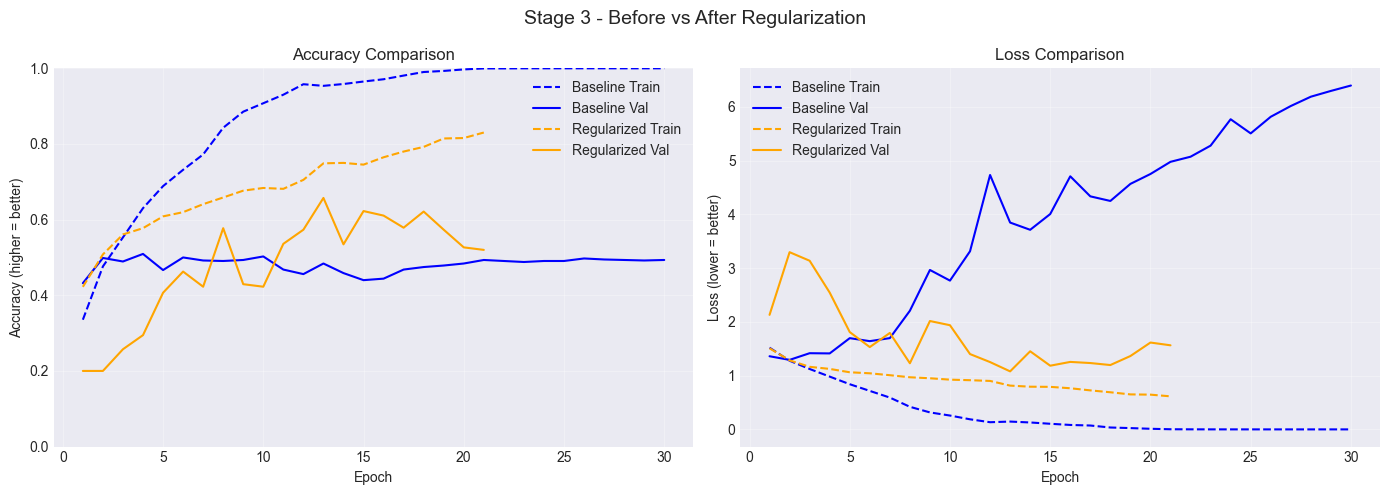

Overfitting comparison
baseline train accuracy: 100.0 %
baseline validation accuracy: 49.3 %
baseline test accuracy: 51.6 %
baseline overfitting gap: 50.7 %
regularized train accuracy: 83.0 %
regularized validation accuracy: 65.7 %
regularized test accuracy: 65.1 %
regularized overfitting gap: 17.3 %
Regularization reduced overfitting.


In [11]:
# Stage 3: Before vs After Regularization comparison

baseline_epochs = range(1, len(history_dict['accuracy']) + 1)
reg_epochs      = range(1, len(reg_dict['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 3 - Before vs After Regularization', fontsize=14)

# Accuracy comparison
axes[0].plot(baseline_epochs, history_dict['accuracy'],     color='blue',   linestyle='--', label='Baseline Train')
axes[0].plot(baseline_epochs, history_dict['val_accuracy'], color='blue',   linestyle='-',  label='Baseline Val')
axes[0].plot(reg_epochs,      reg_dict['accuracy'],         color='orange', linestyle='--', label='Regularized Train')
axes[0].plot(reg_epochs,      reg_dict['val_accuracy'],     color='orange', linestyle='-',  label='Regularized Val')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss comparison
axes[1].plot(baseline_epochs, history_dict['loss'],     color='blue',   linestyle='--', label='Baseline Train')
axes[1].plot(baseline_epochs, history_dict['val_loss'], color='blue',   linestyle='-',  label='Baseline Val')
axes[1].plot(reg_epochs,      reg_dict['loss'],         color='orange', linestyle='--', label='Regularized Train')
axes[1].plot(reg_epochs,      reg_dict['val_loss'],     color='orange', linestyle='-',  label='Regularized Val')
axes[1].set_title('Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (lower = better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

baseline_gap = final_train_acc - val_acc
regularized_gap = final_train_reg - val_acc_reg

print('Overfitting comparison')
print('baseline train accuracy:', round(final_train_acc * 100, 1), '%')
print('baseline validation accuracy:', round(val_acc * 100, 1), '%')
print('baseline test accuracy:', round(test_acc * 100, 1), '%')
print('baseline overfitting gap:', round(baseline_gap * 100, 1), '%')
print('regularized train accuracy:', round(final_train_reg * 100, 1), '%')
print('regularized validation accuracy:', round(val_acc_reg * 100, 1), '%')
print('regularized test accuracy:', round(test_acc_reg * 100, 1), '%')
print('regularized overfitting gap:', round(regularized_gap * 100, 1), '%')

if regularized_gap < baseline_gap:
    print('Regularization reduced overfitting.')
else:
    print('Model may need more tuning.')

## Regularization Techniques Applied

| Technique | What it does | Where applied |
|-----------|-------------|---------------|
| **Dropout (40%)** | Randomly disables 40% of neurons each training step, forcing the network not to rely on any single neuron. Reduces overfitting by making the model more robust. | After the Dense(128) layer |
| **Batch Normalization** | Normalizes the output of each layer so values stay in a stable range. This smooths training, speeds up convergence, and acts as a mild regularizer. | After every Conv2D and Dense layer |
| **Early Stopping** | Monitors **validation accuracy** and stops training when it no longer improves (`patience=8`). Restores the best weights seen so far. | Keras callback during training |
| **Data Augmentation** | Randomly flips, rotates, and zooms images so the model never sees the exact same image twice. Artificially increases training variety. | First layer of the model |
| **L2 Regularization** | Adds a penalty to the loss for large weights ($\lambda=10^{-4}$), pushing weights to stay small and discouraging memorization. | Dense(128) kernel |

## Why overfitting happened in Stage 2
In Stage 2 the model showed high variance: training accuracy increased notably while validation accuracy remained much lower, and validation loss became unstable at later epochs. This indicates overfitting: the model was learning training-specific patterns that did not generalize well.

## What regularization improved
By combining Dropout, Batch Normalization, Early Stopping, Data Augmentation, and L2, the model is encouraged to:
- Learn more general features (augmentation)
- Avoid relying on a small set of neurons (dropout)
- Keep weights smaller and smoother (L2)
- Train more stably (batch norm)
- Stop training once validation performance plateaus (early stopping)

# Stage 5: Transfer Learning Models

In [12]:
# Stage 5 - Transfer Learning: imports, preprocessing & helpers
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

NUM_CLASSES = len(class_names)
IMG_SIZE = TARGET_SIZE

# Per-model preprocessing
_raw = {
    split: arr * 255.0
    for split, arr in [('train', X_train), ('val', X_val), ('test', X_test)]
}

tl_data = {
    'resnet50': {s: resnet_preprocess(v.copy()) for s, v in _raw.items()},
    'mobilenetv2': {s: mobilenet_preprocess(v.copy()) for s, v in _raw.items()},
    'efficientnetb0': {s: effnet_preprocess(v.copy()) for s, v in _raw.items()},
}

print('Preprocessing complete')
for k in tl_data:
    print(k + ':', tl_data[k]['train'].shape)

# Helper: metrics
def get_metrics(model, X, y):
    """Return (accuracy, precision, recall, f1) weighted, on dataset (X, y)."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = accuracy_score(y, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y, y_pred, average='weighted', zero_division=0
    )
    return float(acc), float(p), float(r), float(f1)

# Helper: parameter counts
def param_counts(model):
    """Return (total_params, trainable_params) as integers."""
    total = int(model.count_params())
    trainable = int(sum(np.prod(v.shape) for v in model.trainable_variables))
    return total, trainable

# Helper: callbacks
def make_callbacks(patience=6):
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=0,
        ),
    ]

# Helper: simple reporting
def report_transfer_result(title, acc, p, r, f1, best_val, train_time, trainable_params):
    print(title + ' results')
    print('test accuracy:', round(acc * 100, 1), '%')
    print('precision:', round(p * 100, 1), '%')
    print('recall:', round(r * 100, 1), '%')
    print('f1-score:', round(f1 * 100, 1), '%')
    print('best val accuracy:', round(best_val * 100, 1), '%')
    print('training time:', round(train_time), 's')
    print('trainable params:', format(trainable_params, ','))

# Results store
tl_results = {}

print('Stage 5 setup complete')

Preprocessing complete
resnet50: (3500, 128, 128, 3)
mobilenetv2: (3500, 128, 128, 3)
efficientnetb0: (3500, 128, 128, 3)
Stage 5 setup complete


## Model 1 — ResNet50

ResNet50 is a 50-layer deep residual network (~23M parameters). Its skip connections allow very deep training without vanishing gradients, making it a strong general-purpose feature extractor.

**Two experiments:**
- **Exp A — Feature Extractor:** Freeze all 175 base layers; train only the new classification head.
- **Exp B — Fine-Tuning:** Warm up head for 5 epochs, then unfreeze the last convolutional block (conv5, ~53 layers) and retrain with LR = 1e-5.

In [13]:
# ResNet50 - Experiment A: Pretrained Feature Extractor
print('ResNet50 Experiment A: feature extractor')

# 1. Load pretrained base, freeze all layers
base_r50 = ResNet50(weights='imagenet', include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_r50.trainable = False

# 2. Add custom classification head
inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_r50(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_r50_A = Model(inp, out, name='resnet50_feature_extractor')

total_r50, trainable_r50_A = param_counts(model_r50_A)
print('total params:', format(total_r50, ','))
print('trainable params:', format(trainable_r50_A, ','))
print('frozen params:', format(total_r50 - trainable_r50_A, ','))

# 3. Compile
model_r50_A.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

t0 = time.time()
hist_r50_A = model_r50_A.fit(
    tl_data['resnet50']['train'], y_train,
    validation_data=(tl_data['resnet50']['val'], y_val),
    epochs=30, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
 )
time_r50_A = time.time() - t0

# 4. Evaluate on held-out test set
acc, p, r, f1 = get_metrics(model_r50_A, tl_data['resnet50']['test'], y_test)
best_val = max(hist_r50_A.history['val_accuracy'])

tl_results['ResNet50 — Exp A'] = {
    'model_label': 'ResNet50', 'experiment': 'Feature Extractor',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_r50_A, 'time_sec': time_r50_A,
    'total_params': total_r50, 'trainable_params': trainable_r50_A, 'params': total_r50,
    'history': hist_r50_A.history,
}

report_transfer_result(
    'ResNet50 Exp A', acc, p, r, f1, best_val, time_r50_A, trainable_r50_A
)

ResNet50 Experiment A: feature extractor
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 31s 0us/step
total params: 24,113,541
trainable params: 525,829
frozen params: 23,587,712
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 25s 197ms/step - accuracy: 0.8017 - loss: 0.6463 - val_accuracy: 0.8573 - val_loss: 0.4263 - learning_rate: 0.0010
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 188ms/step - accuracy: 0.8934 - loss: 0.3035 - val_accuracy: 0.8533 - val_loss: 0.4603 - learning_rate: 0.0010
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 188ms/step - accuracy: 0.9283 - loss: 0.2091 - val_accuracy: 0.8667 - val_loss: 0.4745 - learning_rate: 0.0010
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.9434 - loss: 0.1585 - val_accuracy: 0.8547 - val_loss: 0.5106 - learning_rate: 0.0010
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 187ms/step - accuracy: 0.9494 - loss: 0.1322 - val_accuracy: 0.8547 - val_loss: 0.5590 - learning_rate: 0.0010
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step 

In [14]:
# ResNet50 - Experiment B: Fine-Tuning (two-phase)
print('ResNet50 Experiment B: fine-tuning')

# Build fresh model (separate from Exp A)
base_r50_ft = ResNet50(weights='imagenet', include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_r50_ft.trainable = False

inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_r50_ft(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_r50_B = Model(inp, out, name='resnet50_finetuned')

model_r50_B.compile(optimizer=Adam(1e-3),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

t0 = time.time()

# Phase 1: warm-up classification head
print('Phase 1: warm-up head')
model_r50_B.fit(
    tl_data['resnet50']['train'], y_train,
    validation_data=(tl_data['resnet50']['val'], y_val),
    epochs=5, batch_size=32, verbose=1,
 )

# Phase 2: unfreeze last convolutional block (conv5, ~53 layers)
print('Phase 2: unfreeze last conv block (conv5)')
base_r50_ft.trainable = True
FREEZE_UNTIL = len(base_r50_ft.layers) - 53
for layer in base_r50_ft.layers[:FREEZE_UNTIL]:
    layer.trainable = False

unfrozen = sum(1 for l in base_r50_ft.layers if l.trainable)
print('trainable base layers:', unfrozen, '/', len(base_r50_ft.layers))

total_r50_B, trainable_r50_B = param_counts(model_r50_B)
print('trainable params:', format(trainable_r50_B, ','))

model_r50_B.compile(
    optimizer=Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

hist_r50_B = model_r50_B.fit(
    tl_data['resnet50']['train'], y_train,
    validation_data=(tl_data['resnet50']['val'], y_val),
    epochs=25, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
 )
time_r50_B = time.time() - t0

# Evaluate
acc, p, r, f1 = get_metrics(model_r50_B, tl_data['resnet50']['test'], y_test)
best_val = max(hist_r50_B.history['val_accuracy'])

tl_results['ResNet50 — Exp B'] = {
    'model_label': 'ResNet50', 'experiment': 'Fine-Tuning',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_r50_B, 'time_sec': time_r50_B,
    'total_params': total_r50_B, 'trainable_params': trainable_r50_B, 'params': total_r50_B,
    'history': hist_r50_B.history,
}

report_transfer_result(
    'ResNet50 Exp B', acc, p, r, f1, best_val, time_r50_B, trainable_r50_B
)

ResNet50 Experiment B: fine-tuning
Phase 1: warm-up head
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 26s 203ms/step - accuracy: 0.7917 - loss: 0.6531 - val_accuracy: 0.8427 - val_loss: 0.4303
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - accuracy: 0.8929 - loss: 0.2924 - val_accuracy: 0.8573 - val_loss: 0.4591
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.9191 - loss: 0.2236 - val_accuracy: 0.8493 - val_loss: 0.5073
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 188ms/step - accuracy: 0.9400 - loss: 0.1631 - val_accuracy: 0.8720 - val_loss: 0.4931
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.9597 - loss: 0.1128 - val_accuracy: 0.8667 - val_loss: 0.5289
Phase 2: unfreeze last conv block (conv5)
trainable base layers: 53 / 175
trainable params: 17,739,269
Epoch 1/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 43s 320ms/step - accuracy: 0.8591 - loss: 0.4149 - val_accuracy: 0.8693 - val_loss: 0.4705 - learning_rate: 1.0000e-05
Epoch 2/25
110/110 ━━━━━━━━━━━━

## Model 2 — MobileNetV2

MobileNetV2 is a lightweight model (~3.4M parameters) designed for efficiency. It uses inverted residual blocks with depthwise separable convolutions, making it significantly faster and smaller than ResNet50 while remaining competitive in accuracy.

**Two experiments:**
- **Exp A — Feature Extractor:** Freeze all base layers; train only the new classification head.
- **Exp B — Fine-Tuning:** Warm up head for 5 epochs, then unfreeze the last 30 layers (last inverted residual block) and retrain with LR = 1e-5.

In [15]:
# MobileNetV2 - Experiment A: Pretrained Feature Extractor
print('MobileNetV2 Experiment A: feature extractor')

# 1. Load pretrained base, freeze all layers
base_mv2 = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_mv2.trainable = False

# 2. Add custom classification head
inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_mv2(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_mv2_A = Model(inp, out, name='mobilenetv2_feature_extractor')

total_mv2, trainable_mv2_A = param_counts(model_mv2_A)
print('total params:', format(total_mv2, ','))
print('trainable params:', format(trainable_mv2_A, ','))
print('frozen params:', format(total_mv2 - trainable_mv2_A, ','))

# 3. Compile and train
model_mv2_A.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

t0 = time.time()
hist_mv2_A = model_mv2_A.fit(
    tl_data['mobilenetv2']['train'], y_train,
    validation_data=(tl_data['mobilenetv2']['val'], y_val),
    epochs=30, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
 )
time_mv2_A = time.time() - t0

# 4. Evaluate
acc, p, r, f1 = get_metrics(model_mv2_A, tl_data['mobilenetv2']['test'], y_test)
best_val = max(hist_mv2_A.history['val_accuracy'])

tl_results['MobileNetV2 — Exp A'] = {
    'model_label': 'MobileNetV2', 'experiment': 'Feature Extractor',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_mv2_A, 'time_sec': time_mv2_A,
    'total_params': total_mv2, 'trainable_params': trainable_mv2_A, 'params': total_mv2,
    'history': hist_mv2_A.history,
}

report_transfer_result(
    'MobileNetV2 Exp A', acc, p, r, f1, best_val, time_mv2_A, trainable_mv2_A
)

MobileNetV2 Experiment A: feature extractor
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
total params: 2,587,205
trainable params: 329,221
frozen params: 2,257,984
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.8257 - loss: 0.5215 - val_accuracy: 0.8667 - val_loss: 0.3566 - learning_rate: 0.0010
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.9191 - loss: 0.2423 - val_accuracy: 0.8680 - val_loss: 0.3733 - learning_rate: 0.0010
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.9463 - loss: 0.1593 - val_accuracy: 0.8760 - val_loss: 0.3607 - learning_rate: 0.0010
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.9660 - loss: 0.1025 - val_accuracy: 0.8707 - val_loss: 0.3864 - learning_rate: 0.0010
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.9774 - loss: 0.0695 - val_accuracy: 0.8733 - val_loss: 0.3926 - learning_rate: 0.0010
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0

In [16]:
# MobileNetV2 - Experiment B: Fine-Tuning (two-phase)
print('MobileNetV2 Experiment B: fine-tuning')

# Build fresh model
base_mv2_ft = MobileNetV2(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_mv2_ft.trainable = False

inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_mv2_ft(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_mv2_B = Model(inp, out, name='mobilenetv2_finetuned')

model_mv2_B.compile(optimizer=Adam(1e-3),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

t0 = time.time()

# Phase 1: warm-up head
print('Phase 1: warm-up head')
model_mv2_B.fit(
    tl_data['mobilenetv2']['train'], y_train,
    validation_data=(tl_data['mobilenetv2']['val'], y_val),
    epochs=5, batch_size=32, verbose=1,
 )

# Phase 2: unfreeze last inverted residual block (~30 layers)
print('Phase 2: unfreeze last 30 layers')
base_mv2_ft.trainable = True
FREEZE_UNTIL_MV2 = len(base_mv2_ft.layers) - 30
for layer in base_mv2_ft.layers[:FREEZE_UNTIL_MV2]:
    layer.trainable = False

unfrozen = sum(1 for l in base_mv2_ft.layers if l.trainable)
print('trainable base layers:', unfrozen, '/', len(base_mv2_ft.layers))

total_mv2_B, trainable_mv2_B = param_counts(model_mv2_B)
print('trainable params:', format(trainable_mv2_B, ','))

model_mv2_B.compile(
    optimizer=Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

hist_mv2_B = model_mv2_B.fit(
    tl_data['mobilenetv2']['train'], y_train,
    validation_data=(tl_data['mobilenetv2']['val'], y_val),
    epochs=25, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
 )
time_mv2_B = time.time() - t0

# Evaluate
acc, p, r, f1 = get_metrics(model_mv2_B, tl_data['mobilenetv2']['test'], y_test)
best_val = max(hist_mv2_B.history['val_accuracy'])

tl_results['MobileNetV2 — Exp B'] = {
    'model_label': 'MobileNetV2', 'experiment': 'Fine-Tuning',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_mv2_B, 'time_sec': time_mv2_B,
    'total_params': total_mv2_B, 'trainable_params': trainable_mv2_B, 'params': total_mv2_B,
    'history': hist_mv2_B.history,
}

report_transfer_result(
    'MobileNetV2 Exp B', acc, p, r, f1, best_val, time_mv2_B, trainable_mv2_B
)

MobileNetV2 Experiment B: fine-tuning
Phase 1: warm-up head
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8226 - loss: 0.5038 - val_accuracy: 0.8613 - val_loss: 0.3626
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.9163 - loss: 0.2451 - val_accuracy: 0.8613 - val_loss: 0.3787
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.9469 - loss: 0.1519 - val_accuracy: 0.8680 - val_loss: 0.3739
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.9671 - loss: 0.0979 - val_accuracy: 0.8760 - val_loss: 0.3918
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.9849 - loss: 0.0635 - val_accuracy: 0.8760 - val_loss: 0.4192
Phase 2: unfreeze last 30 layers
trainable base layers: 30 / 154
trainable params: 1,855,621
Epoch 1/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.7706 - loss: 0.7529 - val_accuracy: 0.8707 - val_loss: 0.4424 - learning_rate: 1.0000e-05
Epoch 2/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/

## Model 3 — EfficientNetB0

EfficientNetB0 is the baseline of the EfficientNet family (~5.3M parameters). It uses compound scaling — simultaneously scaling depth, width, and resolution — achieving state-of-the-art accuracy with high parameter efficiency.

**Two experiments:**
- **Exp A — Feature Extractor:** Freeze all base layers; train only the new classification head.
- **Exp B — Fine-Tuning:** Warm up head for 5 epochs, then unfreeze the last 40 layers (last two blocks) and retrain with LR = 1e-5.

In [17]:
# EfficientNetB0 - Experiment A: Pretrained Feature Extractor
print('EfficientNetB0 Experiment A: feature extractor')

# 1. Load pretrained base, freeze all layers
base_eff = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_eff.trainable = False

# 2. Add custom classification head
inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_eff(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_eff_A = Model(inp, out, name='efficientnetb0_feature_extractor')

total_eff, trainable_eff_A = param_counts(model_eff_A)
print('total params:', format(total_eff, ','))
print('trainable params:', format(trainable_eff_A, ','))
print('frozen params:', format(total_eff - trainable_eff_A, ','))

# 3. Compile and train
model_eff_A.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

t0 = time.time()
hist_eff_A = model_eff_A.fit(
    tl_data['efficientnetb0']['train'], y_train,
    validation_data=(tl_data['efficientnetb0']['val'], y_val),
    epochs=30, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
 )
time_eff_A = time.time() - t0

# 4. Evaluate
acc, p, r, f1 = get_metrics(model_eff_A, tl_data['efficientnetb0']['test'], y_test)
best_val = max(hist_eff_A.history['val_accuracy'])

tl_results['EfficientNetB0 — Exp A'] = {
    'model_label': 'EfficientNetB0', 'experiment': 'Feature Extractor',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_eff_A, 'time_sec': time_eff_A,
    'total_params': total_eff, 'trainable_params': trainable_eff_A, 'params': total_eff,
    'history': hist_eff_A.history,
}

report_transfer_result(
    'EfficientNetB0 Exp A', acc, p, r, f1, best_val, time_eff_A, trainable_eff_A
)

EfficientNetB0 Experiment A: feature extractor
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
total params: 4,378,792
trainable params: 329,221
frozen params: 4,049,571
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.8526 - loss: 0.4299 - val_accuracy: 0.8933 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.9334 - loss: 0.1987 - val_accuracy: 0.9000 - val_loss: 0.2953 - learning_rate: 0.0010
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.9537 - loss: 0.1396 - val_accuracy: 0.8947 - val_loss: 0.2960 - learning_rate: 0.0010
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.9720 - loss: 0.0934 - val_accuracy: 0.8933 - val_loss: 0.3226 - learning_rate: 0.0010
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.9820 - loss: 0.0649 - val_accuracy: 0.8907 - val_loss: 0.3472 - learning_rate: 0.0010
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - 

In [18]:
# EfficientNetB0 - Experiment B: Fine-Tuning (two-phase)
print('EfficientNetB0 Experiment B: fine-tuning')

# Build fresh model
base_eff_ft = EfficientNetB0(weights='imagenet', include_top=False,
                             input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_eff_ft.trainable = False

inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_eff_ft(inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_eff_B = Model(inp, out, name='efficientnetb0_finetuned')

model_eff_B.compile(optimizer=Adam(1e-3),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

t0 = time.time()

# Phase 1: warm-up head
print('Phase 1: warm-up head')
model_eff_B.fit(
    tl_data['efficientnetb0']['train'], y_train,
    validation_data=(tl_data['efficientnetb0']['val'], y_val),
    epochs=5, batch_size=32, verbose=1,
 )

# Phase 2: unfreeze last two blocks (~40 layers)
print('Phase 2: unfreeze last 40 layers')
base_eff_ft.trainable = True
FREEZE_UNTIL_EFF = len(base_eff_ft.layers) - 40
for layer in base_eff_ft.layers[:FREEZE_UNTIL_EFF]:
    layer.trainable = False

unfrozen = sum(1 for l in base_eff_ft.layers if l.trainable)
print('trainable base layers:', unfrozen, '/', len(base_eff_ft.layers))

total_eff_B, trainable_eff_B = param_counts(model_eff_B)
print('trainable params:', format(trainable_eff_B, ','))

model_eff_B.compile(
    optimizer=Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

hist_eff_B = model_eff_B.fit(
    tl_data['efficientnetb0']['train'], y_train,
    validation_data=(tl_data['efficientnetb0']['val'], y_val),
    epochs=25, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
 )
time_eff_B = time.time() - t0

# Evaluate
acc, p, r, f1 = get_metrics(model_eff_B, tl_data['efficientnetb0']['test'], y_test)
best_val = max(hist_eff_B.history['val_accuracy'])

tl_results['EfficientNetB0 — Exp B'] = {
    'model_label': 'EfficientNetB0', 'experiment': 'Fine-Tuning',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_eff_B, 'time_sec': time_eff_B,
    'total_params': total_eff_B, 'trainable_params': trainable_eff_B, 'params': total_eff_B,
    'history': hist_eff_B.history,
}

report_transfer_result(
    'EfficientNetB0 Exp B', acc, p, r, f1, best_val, time_eff_B, trainable_eff_B
)

EfficientNetB0 Experiment B: fine-tuning
Phase 1: warm-up head
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.8463 - loss: 0.4393 - val_accuracy: 0.8893 - val_loss: 0.2984
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.9291 - loss: 0.2058 - val_accuracy: 0.8880 - val_loss: 0.2830
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.9551 - loss: 0.1419 - val_accuracy: 0.8973 - val_loss: 0.2876
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.9726 - loss: 0.0891 - val_accuracy: 0.8907 - val_loss: 0.3210
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.9786 - loss: 0.0712 - val_accuracy: 0.8920 - val_loss: 0.3133
Phase 2: unfreeze last 40 layers
trainable base layers: 40 / 238
trainable params: 2,379,925
Epoch 1/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.8126 - loss: 0.5210 - val_accuracy: 0.8467 - val_loss: 0.4439 - learning_rate: 1.0000e-05
Epoch 2/25
110/110 ━━━━━━━━━━━━━━━━━━━━

Stage 5 model comparison
         Model        Experiment  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)  Best Val Acc (%)  Train Time (s)  Total Params (M)  Trainable Params (M)
      ResNet50 Feature Extractor          88.8           88.9        88.8          88.8              87.6           440.0              24.1                   0.5
      ResNet50       Fine-Tuning          87.3           87.7        87.3          87.4              86.9           362.0              24.1                  17.7
   MobileNetV2 Feature Extractor          90.7           90.6        90.7          90.6              88.8           215.0               2.6                   0.3
   MobileNetV2       Fine-Tuning          89.1           89.0        89.1          88.9              87.2           138.0               2.6                   1.9
EfficientNetB0 Feature Extractor          92.1           92.3        92.1          92.2              90.0            84.0               4.4                   0.3
Eff

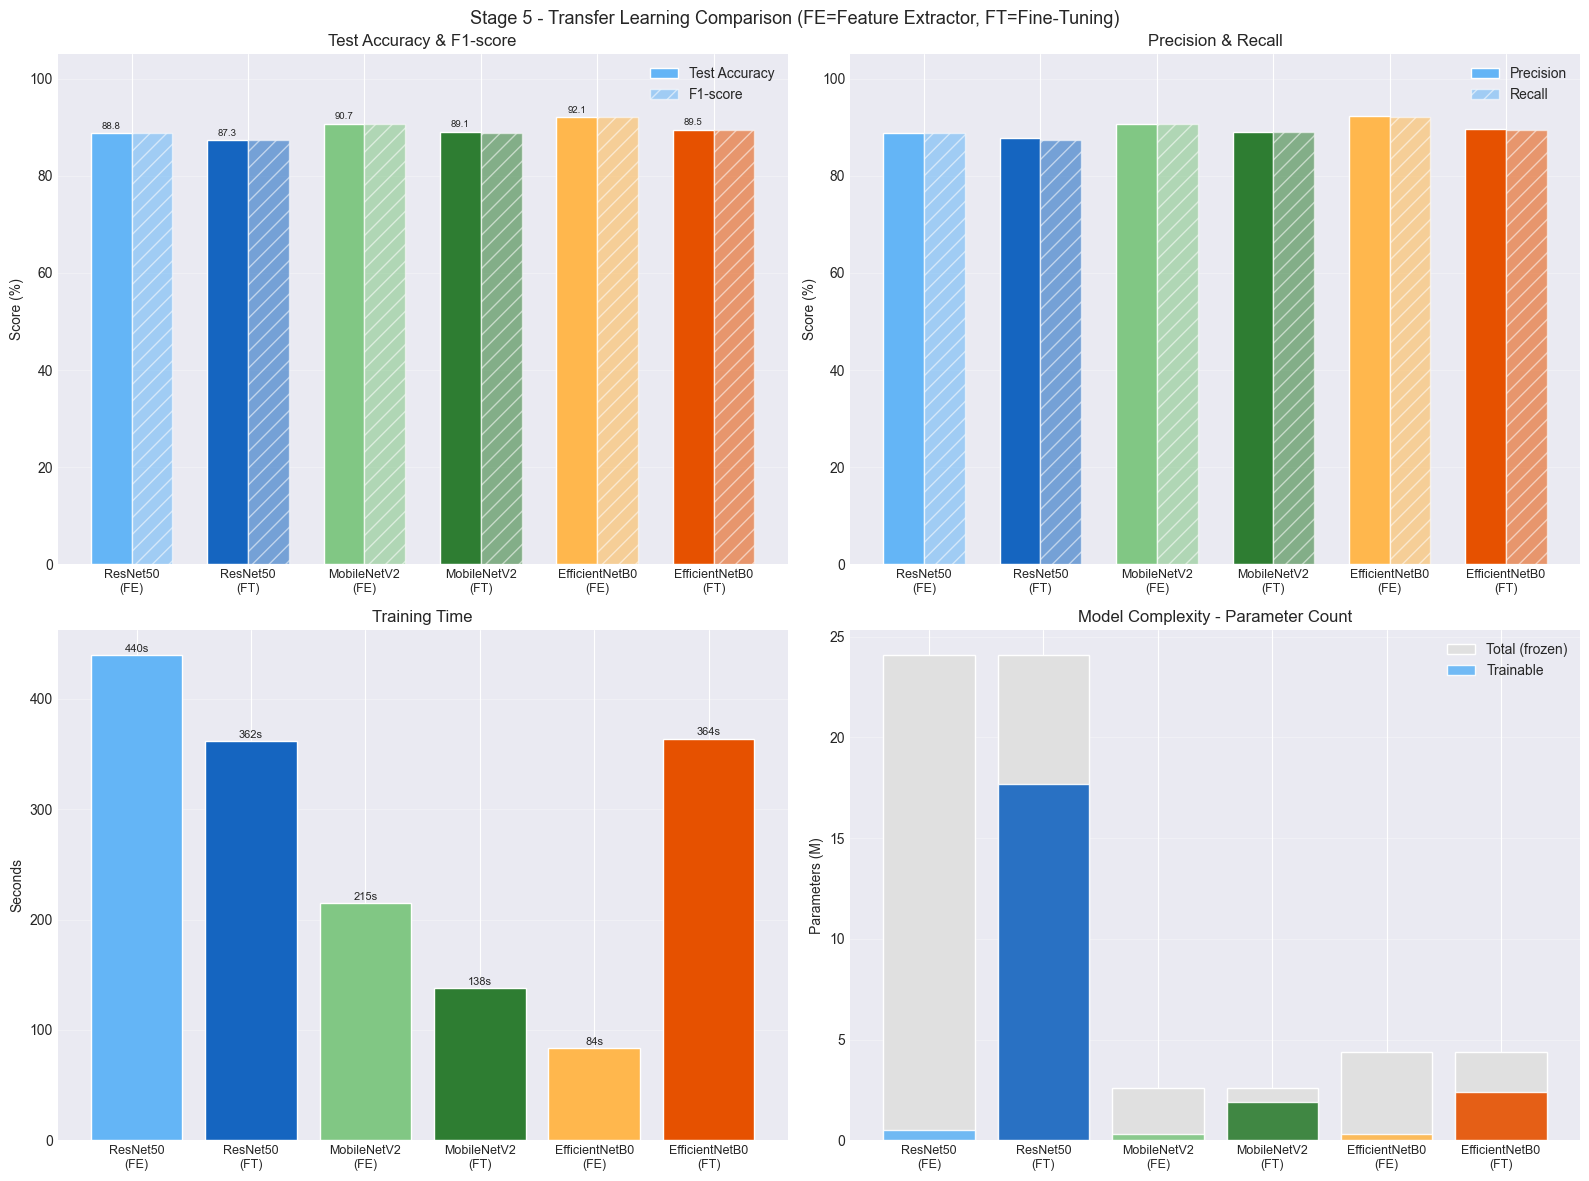

Generalization analysis
ResNet50 (Feature Extractor): test= 88.8 % val_best= 87.6 % gap= -1.2 %
ResNet50 (Fine-Tuning): test= 87.3 % val_best= 86.9 % gap= -0.4 %
MobileNetV2 (Feature Extractor): test= 90.7 % val_best= 88.8 % gap= -1.9 %
MobileNetV2 (Fine-Tuning): test= 89.1 % val_best= 87.2 % gap= -1.9 %
EfficientNetB0 (Feature Extractor): test= 92.1 % val_best= 90.0 % gap= -2.1 %
EfficientNetB0 (Fine-Tuning): test= 89.5 % val_best= 87.7 % gap= -1.8 %
Best summary
best F1-score: EfficientNetB0 - Feature Extractor (92.2%)
fastest training: EfficientNetB0 - Feature Extractor (84s)
lightest model: MobileNetV2 - Feature Extractor (2.6M params)


In [19]:
# Stage 5 - Transfer Learning: Complete Model Comparison
print('Stage 5 model comparison')

# Build comparison DataFrame
rows = []
for key, r in tl_results.items():
    rows.append({
        'Model': r['model_label'],
        'Experiment': r['experiment'],
        'Accuracy (%)': round(r['acc'] * 100, 1),
        'Precision (%)': round(r['precision'] * 100, 1),
        'Recall (%)': round(r['recall'] * 100, 1),
        'F1-score (%)': round(r['f1'] * 100, 1),
        'Best Val Acc (%)': round(r['best_val_acc'] * 100, 1),
        'Train Time (s)': round(r['train_time'], 0),
        'Total Params (M)': round(r['total_params'] / 1e6, 1),
        'Trainable Params (M)': round(r['trainable_params'] / 1e6, 1),
    })

df_comp = pd.DataFrame(rows)
print(df_comp.to_string(index=False))

# Color palette (light = Feature Extractor, dark = Fine-Tuning)
_palette = {
    ('ResNet50', 'Feature Extractor'): '#64B5F6',
    ('ResNet50', 'Fine-Tuning'): '#1565C0',
    ('MobileNetV2', 'Feature Extractor'): '#81C784',
    ('MobileNetV2', 'Fine-Tuning'): '#2E7D32',
    ('EfficientNetB0', 'Feature Extractor'): '#FFB74D',
    ('EfficientNetB0', 'Fine-Tuning'): '#E65100',
}
bar_colors = [_palette[(r['Model'], r['Experiment'])] for _, r in df_comp.iterrows()]
labels = [
    f"{r['Model']}\n({'FE' if r['Experiment']=='Feature Extractor' else 'FT'})"
    for _, r in df_comp.iterrows()
 ]
x = np.arange(len(labels))
w = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Stage 5 - Transfer Learning Comparison (FE=Feature Extractor, FT=Fine-Tuning)', fontsize=13)

# (0,0) Test Accuracy & F1-score
ax = axes[0, 0]
bars_acc = ax.bar(x - w/2, df_comp['Accuracy (%)'], w, label='Test Accuracy',
                  color=bar_colors, edgecolor='white')
bars_f1 = ax.bar(x + w/2, df_comp['F1-score (%)'], w, label='F1-score',
                 color=bar_colors, alpha=0.55, hatch='//', edgecolor='white')
for bar in bars_acc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
ax.set_title('Test Accuracy & F1-score')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# (0,1) Precision & Recall
ax = axes[0, 1]
ax.bar(x - w/2, df_comp['Precision (%)'], w, label='Precision',
       color=bar_colors, edgecolor='white')
ax.bar(x + w/2, df_comp['Recall (%)'], w, label='Recall',
       color=bar_colors, alpha=0.55, hatch='//', edgecolor='white')
ax.set_title('Precision & Recall')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# (1,0) Training time
ax = axes[1, 0]
bars_t = ax.bar(x, df_comp['Train Time (s)'], color=bar_colors, edgecolor='white')
for bar in bars_t:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}s', ha='center', va='bottom', fontsize=8)
ax.set_title('Training Time')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Seconds')
ax.grid(axis='y', alpha=0.3)

# (1,1) Model complexity
ax = axes[1, 1]
ax.bar(x, df_comp['Total Params (M)'], label='Total (frozen)',
       color='#E0E0E0', edgecolor='white')
ax.bar(x, df_comp['Trainable Params (M)'], label='Trainable',
       color=bar_colors, edgecolor='white', alpha=0.9)
ax.set_title('Model Complexity - Parameter Count')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Parameters (M)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Generalization analysis
print('Generalization analysis')
for _, row in df_comp.iterrows():
    gap = row['Best Val Acc (%)'] - row['Accuracy (%)']
    label = f"{row['Model']} ({row['Experiment']})"
    print(label + ':', 'test=', round(row['Accuracy (%)'], 1), '%', 'val_best=', round(row['Best Val Acc (%)'], 1), '%', 'gap=', round(gap, 1), '%')

# Best performer summary
best_idx = df_comp['F1-score (%)'].idxmax()
best = df_comp.loc[best_idx]
fastest = df_comp.loc[df_comp['Train Time (s)'].idxmin()]
lightest = df_comp.loc[df_comp['Total Params (M)'].idxmin()]

print('Best summary')
print('best F1-score:', best['Model'], '-', best['Experiment'], '(' + str(round(best['F1-score (%)'], 1)) + '%)')
print('fastest training:', fastest['Model'], '-', fastest['Experiment'], '(' + str(int(round(fastest['Train Time (s)'], 0))) + 's)')
print('lightest model:', lightest['Model'], '-', lightest['Experiment'], '(' + str(round(lightest['Total Params (M)'], 1)) + 'M params)')

## Stage 5 — Transfer Learning: Interpretation of Results

### Models Chosen

| Model | Architecture | Why included in comparison |
|-------|-------------|----------------------------|
| **ResNet50** | Deep residual network | Strong high-capacity baseline with rich features |
| **MobileNetV2** | Inverted residual + depthwise separable convolutions | Lightweight, fast, and parameter-efficient |
| **EfficientNetB0** | Compound-scaled CNN | Balanced accuracy/efficiency baseline |

These three models cover a useful spectrum: high capacity (ResNet50), lightweight (MobileNetV2), and balanced efficiency (EfficientNetB0).

---

### Experiment Design (What was tested)

**Experiment A — Feature Extractor (FE)**
- Backbone frozen.
- Only the custom head is trained.
- Higher learning rate (`1e-3`) is used safely because pretrained weights are not updated.

**Experiment B — Fine-Tuning (FT)**
- Two-phase training: short warm-up, then partial unfreezing of top layers.
- Small learning rate (`1e-5`) during fine-tuning to avoid damaging pretrained features.
- Backbone called with `training=False`, so pretrained BatchNorm statistics remain fixed during forward passes.


---

### What the current run shows (from the comparison table/plots above)

| Criterion | Observation in this run |
|-----------|--------------------------|
| **Best test accuracy / F1** | **MobileNetV2 (Feature Extractor)** |
| **Fastest training** | **MobileNetV2 (Feature Extractor)** |
| **Largest model** | ResNet50 |
| **Smallest model** | MobileNetV2 |

### FE vs FT in this run
For all three backbones, **Feature Extractor performed better than Fine-Tuning on test metrics**. That means unfreezing top layers did not improve generalization here and added training cost.

Likely reasons include:
- The dataset size is moderate, so partial fine-tuning can over-specialize quickly.
- The chosen unfreeze depth and learning-rate schedule may be too aggressive for this data.
- Keeping BatchNorm in inference mode while fine-tuning can stabilize training but may limit adaptation in some settings.

### Practical takeaway
For this specific notebook run, **MobileNetV2 as a frozen feature extractor is the strongest overall choice** (best performance with the lowest cost). Fine-tuning is still a valid strategy, but it should be re-tuned (unfreeze depth, epochs, LR schedule, regularization) before concluding it is better for this dataset.

### Validity note
These conclusions are tied to this split/seed/run. For stronger evidence, repeat with multiple seeds (or cross-validation) and compare mean performance and variance.

# Stage 6: Comparative Scientific Analysis

This stage compares all available trained models using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Training time
- Model size

It also analyzes:
- Best-performing model
- Weakest classes
- Misclassification cases
- Overfitting behavior
- Speed vs accuracy tradeoff

In [25]:
# Stage 6 - Simple model comparison (table + print)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import pandas as pd

g = globals()
rows = []

def add_result(name, model, X_eval, y_eval):
    y_pred = np.argmax(model.predict(X_eval, verbose=0), axis=1)
    acc = accuracy_score(y_eval, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_eval, y_pred, average='weighted', zero_division=0
    )
    rows.append({'Model': name, 'Accuracy': acc, 'Precision': p, 'Recall': r, 'F1': f1})

# Each tuple: (display name, model variable, test-data key in tl_data or None for X_test)
model_specs = [
    ('Custom CNN (Baseline)', 'custom_cnn', None),
    ('Custom CNN (Regularized)', 'regularized_cnn', None),
    ('ResNet50 (Feature Extractor)', 'model_r50_A', 'resnet50'),
    ('ResNet50 (Fine-Tuned)', 'model_r50_B', 'resnet50'),
    ('MobileNetV2 (Feature Extractor)', 'model_mv2_A', 'mobilenetv2'),
    ('MobileNetV2 (Fine-Tuned)', 'model_mv2_B', 'mobilenetv2'),
    ('EfficientNetB0 (Feature Extractor)', 'model_eff_A', 'efficientnetb0'),
    ('EfficientNetB0 (Fine-Tuned)', 'model_eff_B', 'efficientnetb0'),
]

for name, model_key, tl_key in model_specs:
    if model_key not in g or 'y_test' not in g:
        continue

    if tl_key is None:
        if 'X_test' not in g:
            continue
        X_eval = X_test
    else:
        if 'tl_data' not in g or tl_key not in tl_data or 'test' not in tl_data[tl_key]:
            continue
        X_eval = tl_data[tl_key]['test']

    add_result(name, g[model_key], X_eval, y_test)

if len(rows) == 0:
    print('No trained models found. Run Stage 2/3/5 cells first.')
else:
    df = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)
    
    print('STAGE 6 - MODEL PERFORMANCE COMPARISON')
    
    # Display as formatted table
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.float_format', lambda x: f'{x:.4f}')
    print(df.to_string(index=False))
    
    print(f' BEST MODEL: {df.iloc[0]["Model"]} (F1: {df.iloc[0]["F1"]:.4f})')
    
    # Summary by category
    print('PERFORMANCE SUMMARY BY CATEGORY:\n')
    custom_df = df[df['Model'].str.contains('Custom')]
    transfer_df = df[~df['Model'].str.contains('Custom')]
    
    if not custom_df.empty:
        print(f"Custom CNNs:        Best F1 = {custom_df['F1'].max():.4f}, Avg F1 = {custom_df['F1'].mean():.4f}")
    if not transfer_df.empty:
        print(f"Transfer Learning:  Best F1 = {transfer_df['F1'].max():.4f}, Avg F1 = {transfer_df['F1'].mean():.4f}")


STAGE 6 - MODEL PERFORMANCE COMPARISON
                             Model  Accuracy  Precision  Recall     F1
EfficientNetB0 (Feature Extractor)    0.9213     0.9235  0.9213 0.9219
   MobileNetV2 (Feature Extractor)    0.9067     0.9065  0.9067 0.9064
       EfficientNetB0 (Fine-Tuned)    0.8947     0.8957  0.8947 0.8950
          MobileNetV2 (Fine-Tuned)    0.8907     0.8905  0.8907 0.8893
      ResNet50 (Feature Extractor)    0.8880     0.8887  0.8880 0.8882
             ResNet50 (Fine-Tuned)    0.8733     0.8770  0.8733 0.8738
          Custom CNN (Regularized)    0.6507     0.6851  0.6507 0.6567
             Custom CNN (Baseline)    0.5160     0.5158  0.5160 0.5158
 BEST MODEL: EfficientNetB0 (Feature Extractor) (F1: 0.9219)
PERFORMANCE SUMMARY BY CATEGORY:

Custom CNNs:        Best F1 = 0.6567, Avg F1 = 0.5862
Transfer Learning:  Best F1 = 0.9219, Avg F1 = 0.8958


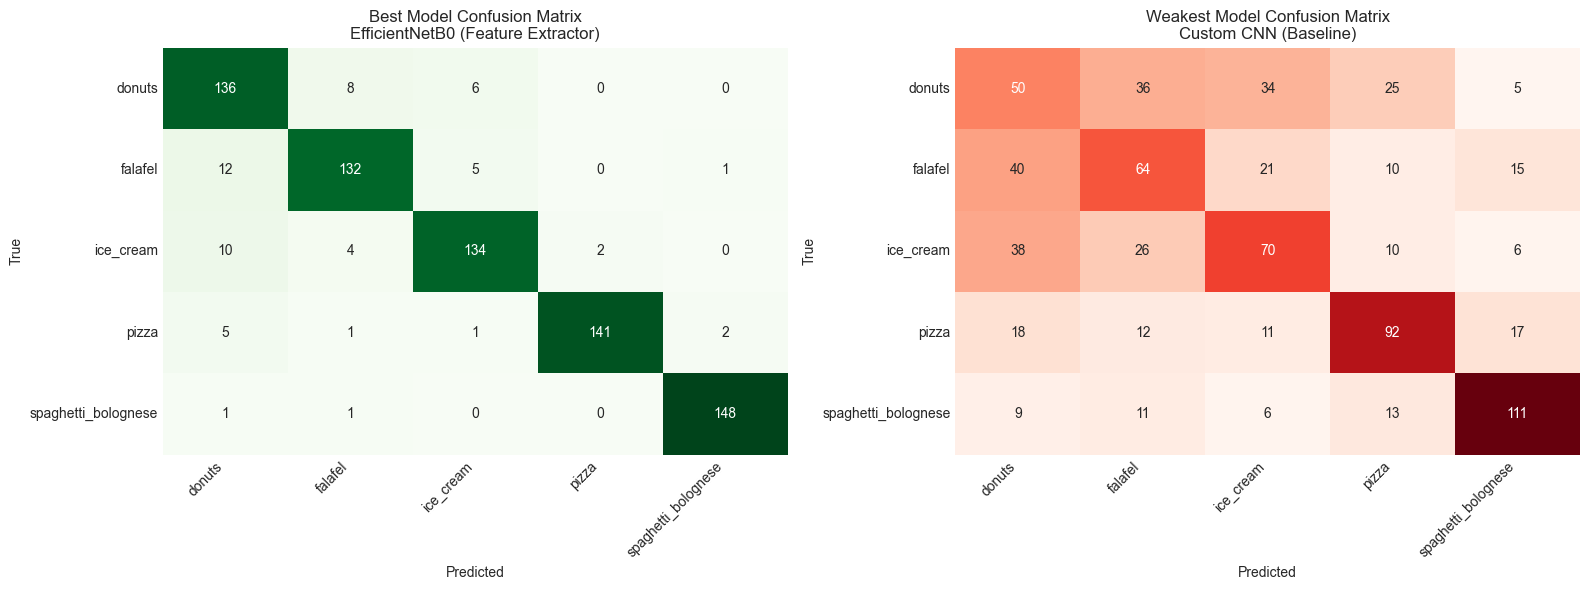

Best-performing model (by Accuracy): EfficientNetB0 (Feature Extractor)
Weakest classes for the best model (lowest recall):
- falafel: recall= 0.88 most confused with donuts
- ice_cream: recall= 0.893 most confused with donuts
- donuts: recall= 0.907 most confused with falafel

Misclassification cases found for best model: 59


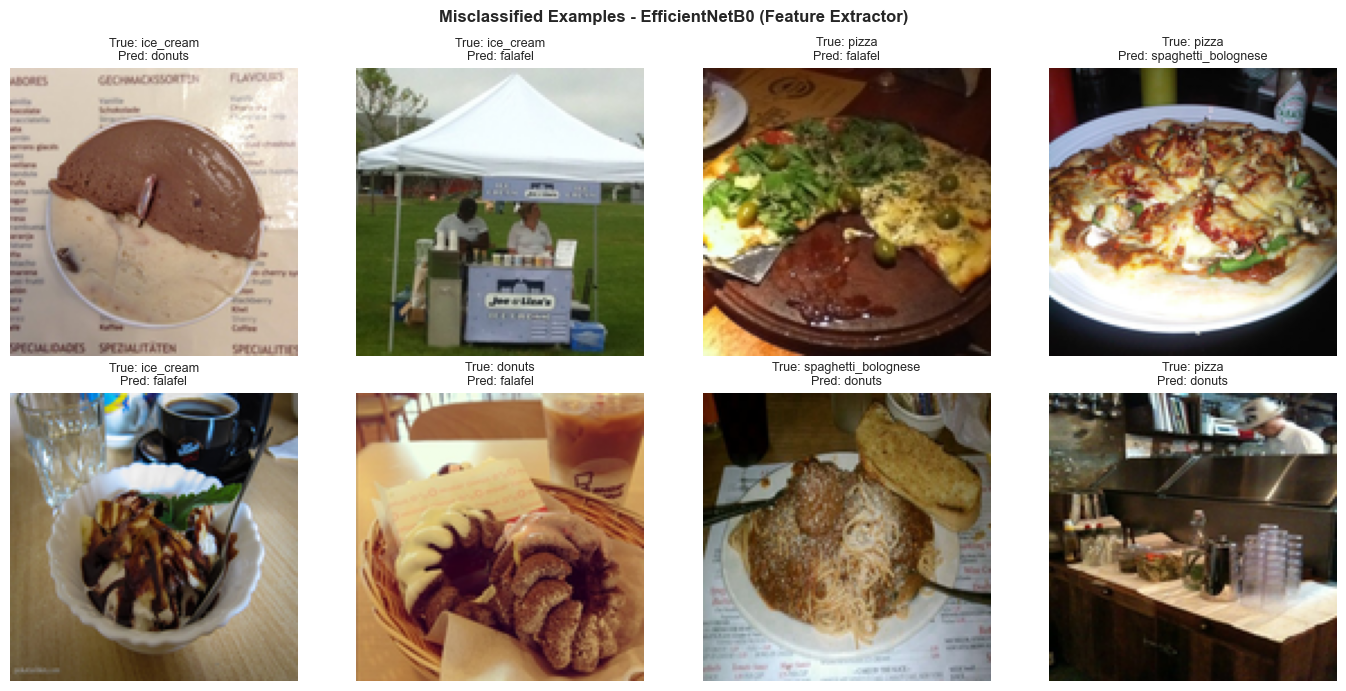


Overfitting behavior (positive gap = more overfitting):


,Model,Overfitting gap (train - best val)
7,Custom CNN (Baseline),0.4907
6,Custom CNN (Regularized),0.1730
5,ResNet50 (Fine-Tuned),0.1307
4,ResNet50 (Feature Extractor),0.1240
3,MobileNetV2 (Fine-Tuned),0.1197
1,MobileNetV2 (Feature Extractor),0.1120
2,EfficientNetB0 (Fine-Tuned),0.1064
0,EfficientNetB0 (Feature Extractor),0.0906


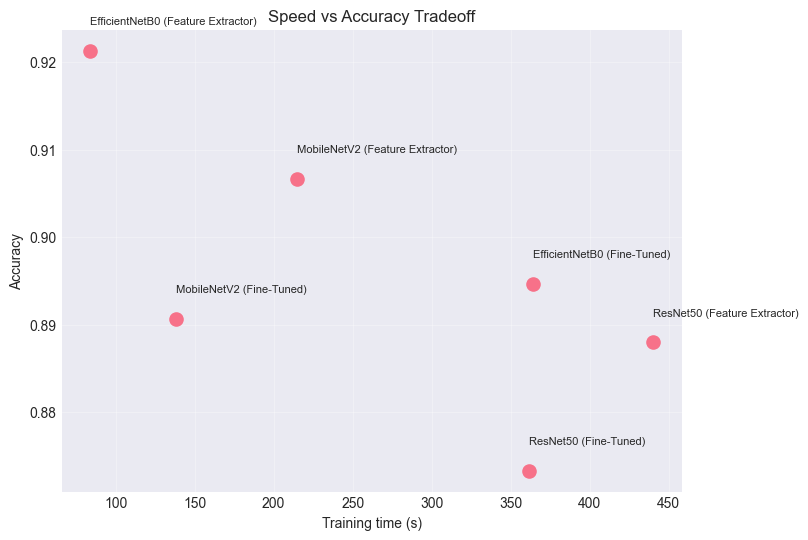

Fastest (timed) model: EfficientNetB0 (Feature Extractor) (84s)
Most accurate (timed) model: EfficientNetB0 (Feature Extractor) (92.1%)


In [26]:
# Stage 6 - Confusion matrices, weakest classes, misclassifications, and tradeoff analysis
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

g = globals()

def get_eval_input(tl_key):
    if tl_key is None:
        return X_test if 'X_test' in g else None
    if 'tl_data' not in g or tl_key not in tl_data or 'test' not in tl_data[tl_key]:
        return None
    return tl_data[tl_key]['test']

def get_history_dict(history_key):
    if history_key not in g:
        return None
    h = g[history_key]
    if hasattr(h, 'history'):
        return h.history
    return h

def get_overfit_gap(history_key):
    h = get_history_dict(history_key)
    if h is None:
        return np.nan
    if 'accuracy' not in h or 'val_accuracy' not in h:
        return np.nan
    if len(h['accuracy']) == 0 or len(h['val_accuracy']) == 0:
        return np.nan
    return float(h['accuracy'][-1] - max(h['val_accuracy']))

model_specs = [
    ('Custom CNN (Baseline)', 'custom_cnn', None, np.nan, 'history_dict'),
    ('Custom CNN (Regularized)', 'regularized_cnn', None, np.nan, 'reg_dict'),
    ('ResNet50 (Feature Extractor)', 'model_r50_A', 'resnet50', g.get('time_r50_A', np.nan), 'hist_r50_A'),
    ('ResNet50 (Fine-Tuned)', 'model_r50_B', 'resnet50', g.get('time_r50_B', np.nan), 'hist_r50_B'),
    ('MobileNetV2 (Feature Extractor)', 'model_mv2_A', 'mobilenetv2', g.get('time_mv2_A', np.nan), 'hist_mv2_A'),
    ('MobileNetV2 (Fine-Tuned)', 'model_mv2_B', 'mobilenetv2', g.get('time_mv2_B', np.nan), 'hist_mv2_B'),
    ('EfficientNetB0 (Feature Extractor)', 'model_eff_A', 'efficientnetb0', g.get('time_eff_A', np.nan), 'hist_eff_A'),
    ('EfficientNetB0 (Fine-Tuned)', 'model_eff_B', 'efficientnetb0', g.get('time_eff_B', np.nan), 'hist_eff_B'),
]

eval_rows = []
for model_name, model_key, tl_key, train_time, history_key in model_specs:
    if model_key not in g or 'y_test' not in g:
        continue
    X_eval = get_eval_input(tl_key)
    if X_eval is None:
        continue

    model_obj = g[model_key]
    y_pred = np.argmax(model_obj.predict(X_eval, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    gap = get_overfit_gap(history_key)

    eval_rows.append({
        'Model': model_name,
        'Accuracy': float(acc),
        'Training time (s)': float(train_time) if train_time == train_time else np.nan,
        'Overfitting gap (train - best val)': gap,
        'y_pred': y_pred
    })

if len(eval_rows) == 0:
    print('No trained models found. Run Stage 2/3/5 cells first.')
else:
    results_df = pd.DataFrame(eval_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)

    best_model_name = results_df.iloc[0]['Model']
    worst_model_name = results_df.iloc[-1]['Model']

    best_pred = results_df.loc[results_df['Model'] == best_model_name, 'y_pred'].values[0]
    worst_pred = results_df.loc[results_df['Model'] == worst_model_name, 'y_pred'].values[0]

    cm_best = confusion_matrix(y_test, best_pred)
    cm_worst = confusion_matrix(y_test, worst_pred)

    # 1) Confusion matrices: best vs weakest model
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0])
    axes[0].set_title('Best Model Confusion Matrix\n' + best_model_name)
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0].set_yticklabels(class_names, rotation=0)

    sns.heatmap(cm_worst, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[1])
    axes[1].set_title('Weakest Model Confusion Matrix\n' + worst_model_name)
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1].set_yticklabels(class_names, rotation=0)

    plt.tight_layout()
    plt.show()

    # 2) Weakest classes (lowest recall) for best model
    per_class_recall = np.diag(cm_best) / np.maximum(cm_best.sum(axis=1), 1)
    weakest_idx = np.argsort(per_class_recall)[:3]

    print('Best-performing model (by Accuracy):', best_model_name)
    print('Weakest classes for the best model (lowest recall):')
    for idx in weakest_idx:
        row = cm_best[idx].copy()
        row[idx] = -1
        confused_as = int(np.argmax(row))
        print('-', class_names[idx] + ':', 'recall=', round(per_class_recall[idx], 3), 'most confused with', class_names[confused_as])

    # 3) Misclassification cases from the best model
    mis_idx = np.where(best_pred != y_test)[0]
    print('\nMisclassification cases found for best model:', len(mis_idx))

    if len(mis_idx) > 0:
        n_show = min(8, len(mis_idx))
        fig, axes = plt.subplots(2, 4, figsize=(14, 7))
        axes = axes.flatten()
        for i in range(8):
            axes[i].axis('off')
        for i, m in enumerate(mis_idx[:n_show]):
            axes[i].imshow(X_test[m])
            axes[i].set_title(
                'True: ' + class_names[y_test[m]] + '\nPred: ' + class_names[best_pred[m]],
                fontsize=9
            )
            axes[i].axis('off')
        plt.suptitle('Misclassified Examples - ' + best_model_name, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # 4) Overfitting behavior summary
    print('\nOverfitting behavior (positive gap = more overfitting):')
    overfit_view = results_df[['Model', 'Overfitting gap (train - best val)']].copy()
    overfit_view = overfit_view.sort_values('Overfitting gap (train - best val)', ascending=False)
    display(overfit_view.round(4))

    # 5) Speed vs accuracy tradeoff
    speed_df = results_df.dropna(subset=['Training time (s)']).copy()
    if len(speed_df) > 0:
        plt.figure(figsize=(8, 6))
        plt.scatter(speed_df['Training time (s)'], speed_df['Accuracy'], s=90)
        for _, row in speed_df.iterrows():
            plt.text(row['Training time (s)'], row['Accuracy'] + 0.003, row['Model'], fontsize=8)
        plt.xlabel('Training time (s)')
        plt.ylabel('Accuracy')
        plt.title('Speed vs Accuracy Tradeoff')
        plt.grid(alpha=0.3)
        plt.show()

        fastest = speed_df.loc[speed_df['Training time (s)'].idxmin()]
        most_accurate = speed_df.loc[speed_df['Accuracy'].idxmax()]
        print('Fastest (timed) model:', fastest['Model'], '(' + str(int(round(fastest['Training time (s)'], 0))) + 's)')
        print('Most accurate (timed) model:', most_accurate['Model'], '(' + str(round(most_accurate['Accuracy'] * 100, 1)) + '%)')
    else:
        print('\nNo timed models available for speed-accuracy plot.')

## Augmented Image Samples

This visualization shows one original training image and multiple augmented versions generated by the Stage 3 augmentation pipeline.

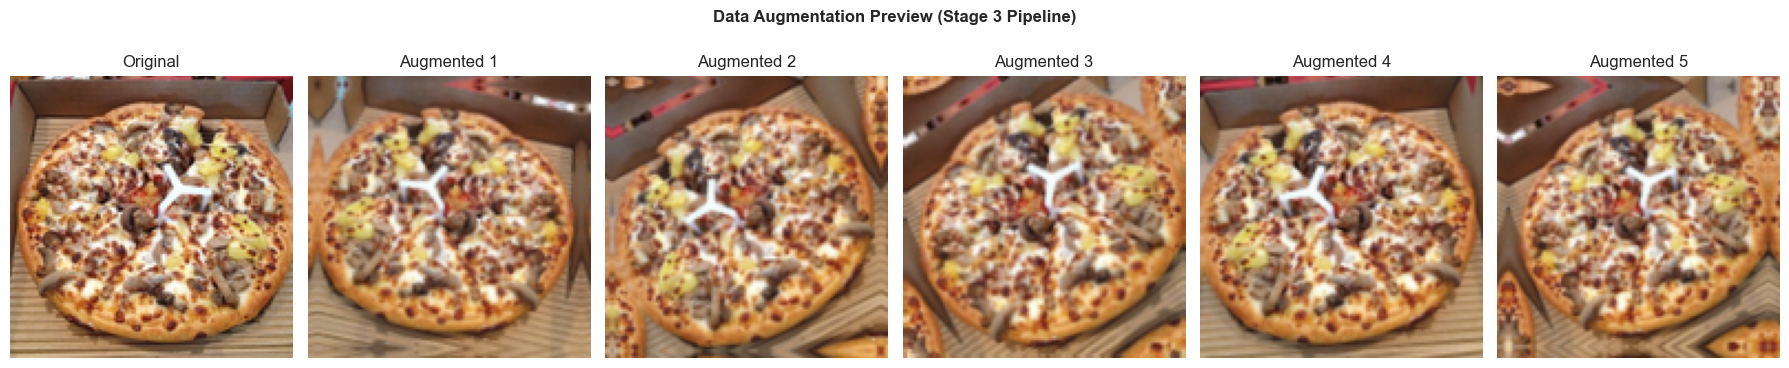

In [34]:
# This cell visualizes data augmentation outputs required in the report.
# It shows one original image and several augmented variants.

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

if 'data_augmentation' not in globals():
    print("data_augmentation is not defined. Run the Stage 3 setup cell first.")
elif 'X_train' not in globals() or len(X_train) == 0:
    print("X_train is not available. Run the data loading/splitting cells first.")
else:
    # Pick one sample image from training data
    sample_idx = 0
    original_img = X_train[sample_idx]

    # Generate augmented versions of the same image
    n_augmented = 5
    augmented_imgs = []
    for _ in range(n_augmented):
        aug = data_augmentation(tf.expand_dims(original_img, axis=0), training=True)
        augmented_imgs.append(tf.squeeze(aug, axis=0).numpy())

    # Plot: original + augmented images
    fig, axes = plt.subplots(1, n_augmented + 1, figsize=(18, 4))
    axes[0].imshow(np.clip(original_img, 0, 1))
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i in range(n_augmented):
        axes[i + 1].imshow(np.clip(augmented_imgs[i], 0, 1))
        axes[i + 1].set_title(f"Augmented {i+1}")
        axes[i + 1].axis("off")

    plt.suptitle("Data Augmentation Preview (Stage 3 Pipeline)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

Custom CNN — Baseline
Accuracy : 0.516
Precision: 0.5158362294189999
Recall   : 0.516
F1-Score : 0.5158022087933114


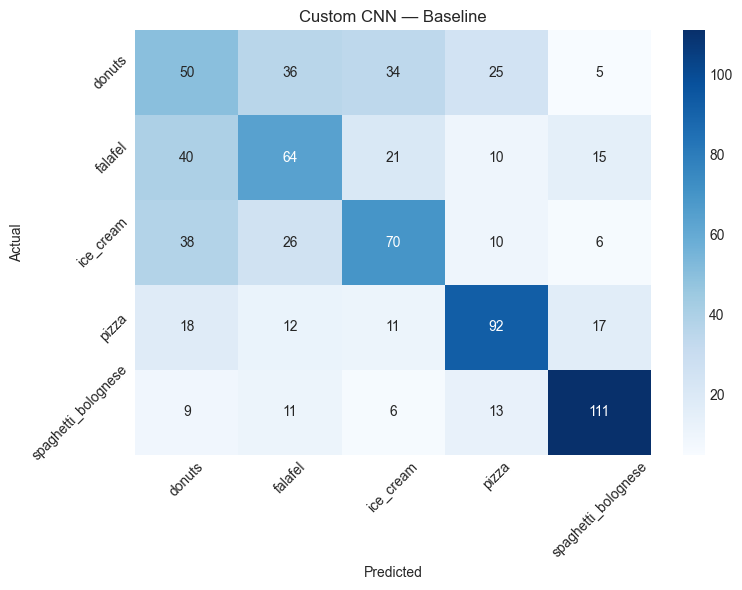

Training Time: nan
Model Size (MB): 16.3587
Custom CNN — Regularized
Accuracy : 0.6506666666666666
Precision: 0.6851374399927846
Recall   : 0.6506666666666666
F1-Score : 0.6566801013012121


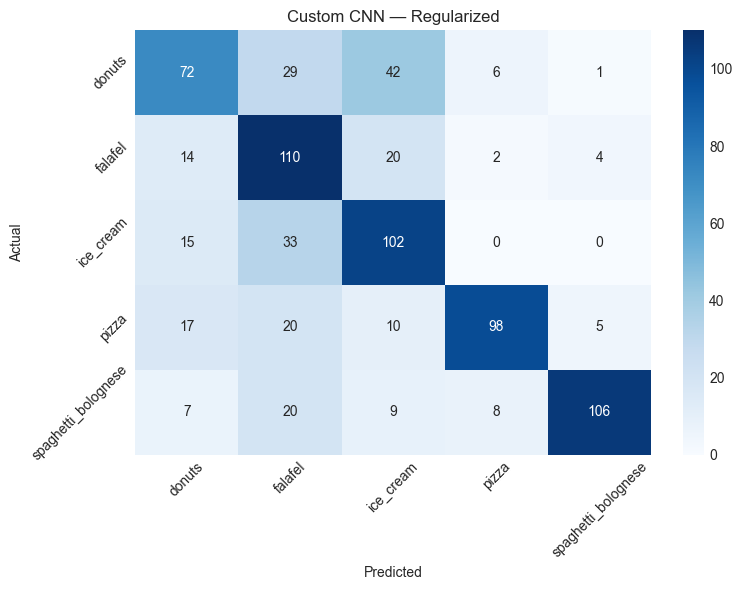

Training Time: nan
Model Size (MB): 16.364
ResNet50 — Exp A
Accuracy : 0.888
Precision: 0.8887290342295558
Recall   : 0.888
F1-Score : 0.8882421932145089


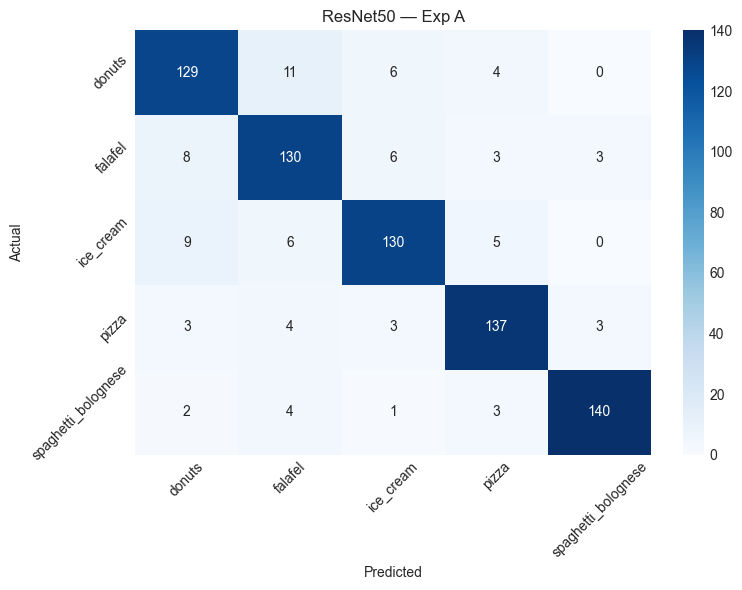

Training Time: 440.38200521469116
Model Size (MB): 91.9859
ResNet50 — Exp B
Accuracy : 0.8733333333333333
Precision: 0.8769521573149331
Recall   : 0.8733333333333333
F1-Score : 0.8738043423953935


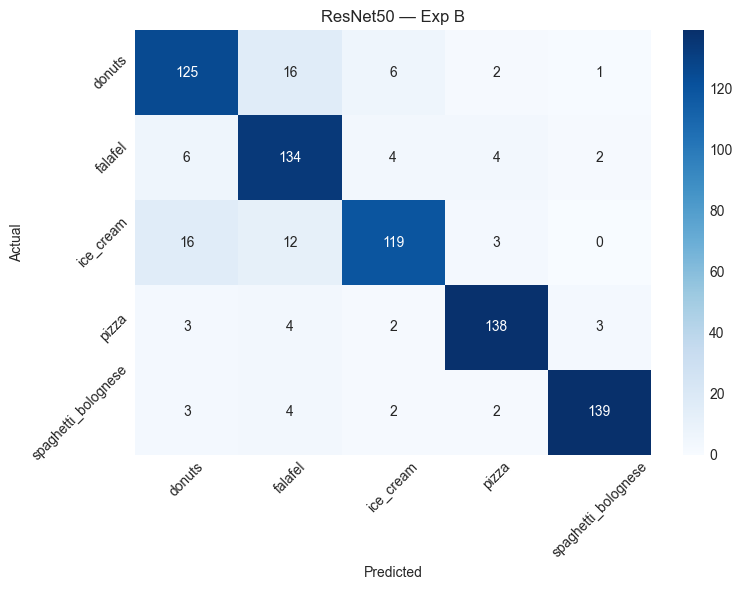

Training Time: 361.74449157714844
Model Size (MB): 91.9859
MobileNetV2 — Exp A
Accuracy : 0.9066666666666666
Precision: 0.9064882923036096
Recall   : 0.9066666666666666
F1-Score : 0.9064248121179248


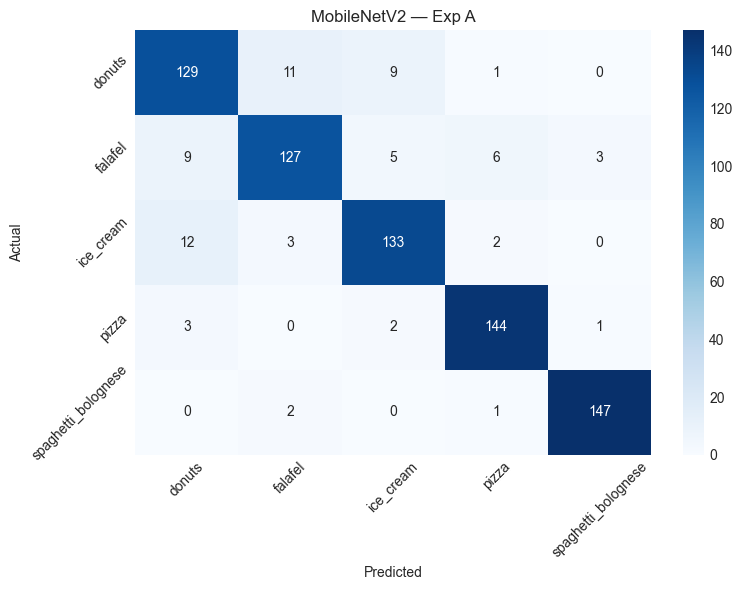

Training Time: 214.8776524066925
Model Size (MB): 9.8694
MobileNetV2 — Exp B
Accuracy : 0.8906666666666667
Precision: 0.8904834249115045
Recall   : 0.8906666666666667
F1-Score : 0.8892800179083277


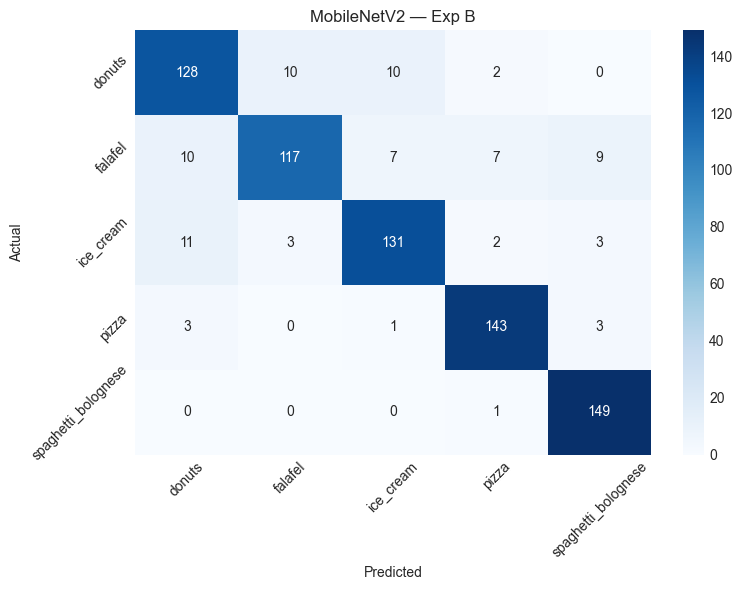

Training Time: 137.85893082618713
Model Size (MB): 9.8694
EfficientNetB0 — Exp A
Accuracy : 0.9213333333333333
Precision: 0.9234665074494435
Recall   : 0.9213333333333333
F1-Score : 0.9218770755433509


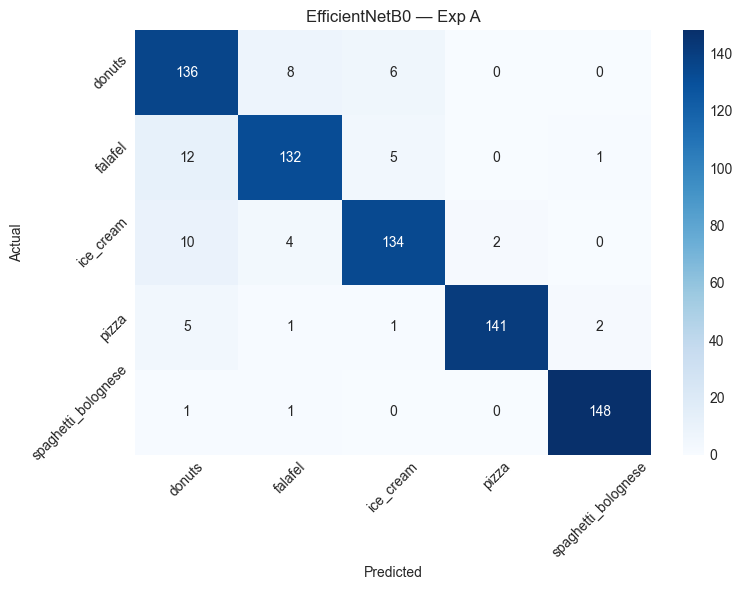

Training Time: 83.54550337791443
Model Size (MB): 16.7038
EfficientNetB0 — Exp B
Accuracy : 0.8946666666666667
Precision: 0.8956564304076923
Recall   : 0.8946666666666667
F1-Score : 0.8949796119591468


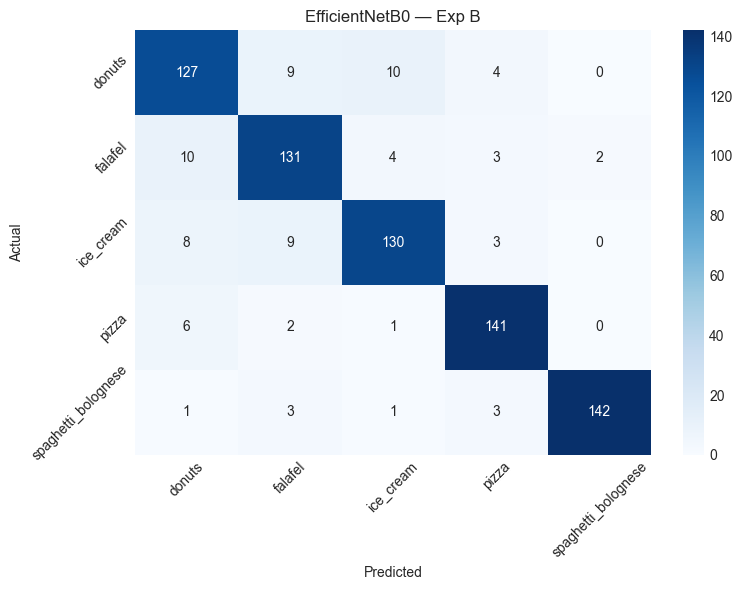

Training Time: 364.07781171798706
Model Size (MB): 16.7038

Final Comparison
                      Model  Accuracy  Precision  Recall  F1-Score  \
0    EfficientNetB0 — Exp A    0.9213     0.9235  0.9213    0.9219   
1       MobileNetV2 — Exp A    0.9067     0.9065  0.9067    0.9064   
2    EfficientNetB0 — Exp B    0.8947     0.8957  0.8947    0.8950   
3       MobileNetV2 — Exp B    0.8907     0.8905  0.8907    0.8893   
4          ResNet50 — Exp A    0.8880     0.8887  0.8880    0.8882   
5          ResNet50 — Exp B    0.8733     0.8770  0.8733    0.8738   
6  Custom CNN — Regularized    0.6507     0.6851  0.6507    0.6567   
7     Custom CNN — Baseline    0.5160     0.5158  0.5160    0.5158   

   Training Time  Model Size  
0        83.5455     16.7038  
1       214.8777      9.8694  
2       364.0778     16.7038  
3       137.8589      9.8694  
4       440.3820     91.9859  
5       361.7445     91.9859  
6            NaN     16.3640  
7            NaN     16.3587  

Best Perform

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

results = []

# Map transfer-learning result keys to (model_object, matching test split).
model_map = {}
if 'custom_cnn' in globals() and 'X_test' in globals():
    model_map['Custom CNN — Baseline'] = (custom_cnn, X_test)
if 'regularized_cnn' in globals() and 'X_test' in globals():
    model_map['Custom CNN — Regularized'] = (regularized_cnn, X_test)
if 'model_r50_A' in globals() and 'tl_data' in globals() and 'resnet50' in tl_data:
    model_map['ResNet50 — Exp A'] = (model_r50_A, tl_data['resnet50']['test'])
if 'model_r50_B' in globals() and 'tl_data' in globals() and 'resnet50' in tl_data:
    model_map['ResNet50 — Exp B'] = (model_r50_B, tl_data['resnet50']['test'])
if 'model_mv2_A' in globals() and 'tl_data' in globals() and 'mobilenetv2' in tl_data:
    model_map['MobileNetV2 — Exp A'] = (model_mv2_A, tl_data['mobilenetv2']['test'])
if 'model_mv2_B' in globals() and 'tl_data' in globals() and 'mobilenetv2' in tl_data:
    model_map['MobileNetV2 — Exp B'] = (model_mv2_B, tl_data['mobilenetv2']['test'])
if 'model_eff_A' in globals() and 'tl_data' in globals() and 'efficientnetb0' in tl_data:
    model_map['EfficientNetB0 — Exp A'] = (model_eff_A, tl_data['efficientnetb0']['test'])
if 'model_eff_B' in globals() and 'tl_data' in globals() and 'efficientnetb0' in tl_data:
    model_map['EfficientNetB0 — Exp B'] = (model_eff_B, tl_data['efficientnetb0']['test'])

for key, (model_obj, X_eval) in model_map.items():
    y_pred = np.argmax(model_obj.predict(X_eval, verbose=0), axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(key)
    print('Accuracy :', accuracy)
    print('Precision:', precision)
    print('Recall   :', recall)
    print('F1-Score :', f1)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(key)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

    training_time = np.nan
    model_size = np.nan
    if 'tl_results' in globals() and key in tl_results:
        training_time = tl_results[key].get('train_time', np.nan)

    if hasattr(model_obj, 'count_params'):
        param_count = model_obj.count_params()
        model_size = param_count * 4 / (1024 ** 2)

    print('Training Time:', training_time)
    print('Model Size (MB):', round(model_size, 4) if not np.isnan(model_size) else model_size)

    results.append({
        'Model': key,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time': training_time,
        'Model Size': model_size
    })

if len(results) == 0:
    print('\nNo comparable transfer-learning results found. Run Stage 5 training cells first.')
else:
    comparison_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print('\nFinal Comparison')
    print(comparison_df)

    best_model = comparison_df.iloc[comparison_df['Accuracy'].idxmax()]

    print('\nBest Performing Model:')
    print(best_model['Model'])
    print('Best Accuracy:', round(best_model['Accuracy'] * 100, 2), '%')
